# Echo State Networks - Architecture Comparison on Increasingly Difficult Synthetic Signals

**Notebook 3** of a research series framed within Antonio Macías Ferrera's Master's thesis
(*General Study of the Reservoir Topology on Echo State Networks*, University of Seville).

This notebook extends the **Phase-B topology study** of Notebook 1 by evaluating three reservoir
architectures - Erdős-Rényi (ER), Watts-Strogatz (WS), and Barabási-Albert (BA) - across a
**progression of ten synthetic signals of increasing complexity**.

Each signal is strictly harder than Notebook 1's baseline by incorporating more periodic components and stronger noise.

For every (signal x architecture) pair we sweep the key structural parameter(s) under 5-fold
temporal cross-validation, identify the optimal topology configuration, and record the best RMSE.
A final **comparison grid** reveals how architecture sensitivity changes as signal difficulty grows.

| Signal | Frequencies | Noise sr | Extra difficulty |
|--------|-------------|---------|------------------|
| NB1 ref. | 3 | 0.05 | - (baseline) |
| **S1** | 4 | 0.12 | +1 incommensurate period (T=83) |
| **S2** | 5 | 0.22 | beating pair (T=50 & T=53, beat≈833 ts) |
| **S3** | 6 | 0.38 | slow amplitude modulation (T_AM=5 000) |
| **S4** | 7 | 0.56 | strong AM (T_AM=3 000) + dense multi-scale beating |
| **S5** | 8 | 0.70 | very strong AM (T_AM=2 000) + extra high-freq T=19 |
| **S6** | 9 | 0.85 | chaotic-like multi-scale beating (T_AM=1 500) |
| **S7** | 10 | 1.00 | double AM envelope (T_AM=2 500 & T_AM=700) |
| **S8** | 11 | 1.20 | triple beating clusters + double AM (T_AM=3 500 & T_AM=500) |
| **S9** | 12 | 1.50 | extreme noise + full non-stationarity (T_AM=4 000 & T_AM=400) |
| **S10** | 13 | 2.00 | maximum AM complexity (T_AM=5 000 & T_AM=300) |

## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Synthetic Signal Definitions](#2-synthetic-signal-definitions)
3. [ESN Configuration & Helper Functions](#3-esn-configuration--helper-functions)
4. [Topology Study - Signal S1](#4-topology-study---signal-s1)
5. [Topology Study - Signal S2](#5-topology-study---signal-s2)
6. [Topology Study - Signal S3](#6-topology-study---signal-s3)
7. [Topology Study - Signal S4](#7-topology-study---signal-s4)
8. [Cross-Signal Architecture Comparison Grid](#8-cross-signal-architecture-comparison-grid)
9. [Final Comparison — Mean RMSE vs. Signal Difficulty](#9-final-comparison--mean-rmse-vs-signal-difficulty)

## 1. Environment Setup

In [2]:
import time
import warnings
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
import reservoirpy as rpy
from reservoirpy.nodes import Reservoir, Ridge
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

print("Library versions")
for lib_name, lib in [("numpy", np), ("pandas", pd), ("reservoirpy", rpy),
                       ("networkx", nx), ("seaborn", sns)]:
    print(f"  {lib_name:15s} {lib.__version__}")


Library versions
  numpy           2.4.2
  pandas          3.0.1
  reservoirpy     0.4.1
  networkx        3.6.1
  seaborn         0.13.2


In [3]:
# ---------------------------------------------------------------------------
# Global configuration
# ---------------------------------------------------------------------------
N_SPLITS  = 10          # temporal CV folds
LAG       = 10          # look-back window (same as Notebook 1)
T         = 15_000      # signal length

os.makedirs("single_hp_outputs_3", exist_ok=True)

print(f"  CV folds    : {N_SPLITS}")
print(f"  Input lag   : {LAG}")
print(f"  Signal len  : {T}")

  CV folds    : 10
  Input lag   : 10
  Signal len  : 15000


## 2. Synthetic Signal Definitions

The 10-signal suite starts with the **exact Notebook 1 baseline** as `S1`:
three incommensurate periods `(50, 127, 310)` plus Gaussian noise with
`sigma = 0.05`.

Signals `S2-S5` then increase difficulty by subsampling the original odd-indexed
signals (former S3, S5, S7, S9), each introducing progressively more periodic
components, stronger amplitude modulation, and denser frequency interference.
Signals `S6-S10` push complexity further with new mechanisms: triple AM envelopes,
frequency modulation, regime switching, multiplicative heteroscedastic noise, and
a full combination of all complexity types.


In [4]:
# ---------------------------------------------------------------------------
# Generate the ten signals
# ---------------------------------------------------------------------------
t_axis = np.arange(T)
BASELINE_PERIODS = (50, 127, 310)

# Shared clean periodic core from Notebook 1
baseline_nb1_clean = (
      np.sin(2 * np.pi * t_axis / BASELINE_PERIODS[0])
    + 0.50 * np.sin(2 * np.pi * t_axis / BASELINE_PERIODS[1])
    + 0.30 * np.sin(2 * np.pi * t_axis / BASELINE_PERIODS[2])
)

# ---- Signal S1: exact Notebook 1 periodic core + sigma=0.05 ---------------
s1 = baseline_nb1_clean + 0.05 * np.random.randn(T)

# ---- Signal S2: 5 freq + near-period beating pair (was S3) ----------------
s2 = (
      baseline_nb1_clean
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.22 * np.random.randn(T)
)

# ---- Signal S3: 7 freq + strong AM (was S5) --------------------------------
am3 = 1.0 + 0.50 * np.sin(2 * np.pi * t_axis / 3000)
s3 = am3 * (
      baseline_nb1_clean
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
) + 0.56 * np.random.randn(T)

# ---- Signal S4: 9 freq + chaotic multi-scale beating (was S7) --------------
am4 = 1.0 + 0.80 * np.sin(2 * np.pi * t_axis / 1500)
s4 = am4 * (
      baseline_nb1_clean
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
    + 0.10 * np.sin(2 * np.pi * t_axis / 19)
    + 0.08 * np.sin(2 * np.pi * t_axis / 71)
) + 0.85 * np.random.randn(T)

# ---- Signal S5: 11 freq + double AM (was S9) -------------------------------
am5 = (1.0 + 0.60 * np.sin(2 * np.pi * t_axis / 3500)) * (1.0 + 0.40 * np.sin(2 * np.pi * t_axis / 500))
s5 = am5 * (
      baseline_nb1_clean
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
    + 0.10 * np.sin(2 * np.pi * t_axis / 19)
    + 0.08 * np.sin(2 * np.pi * t_axis / 71)
    + 0.07 * np.sin(2 * np.pi * t_axis / 29)
    + 0.06 * np.sin(2 * np.pi * t_axis / 13)
) + 1.20 * np.random.randn(T)

# ---- Signal S6: 12 freq + triple AM envelope --------------------------------
# Adds a third fast AM layer (T_AM=120) on top of the double AM from S5,
# creating a three-timescale non-stationary amplitude structure.
am6 = (
    (1.0 + 0.60 * np.sin(2 * np.pi * t_axis / 3500))
  * (1.0 + 0.40 * np.sin(2 * np.pi * t_axis / 500))
  * (1.0 + 0.25 * np.sin(2 * np.pi * t_axis / 120))
)
s6 = am6 * (
      baseline_nb1_clean
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
    + 0.10 * np.sin(2 * np.pi * t_axis / 19)
    + 0.08 * np.sin(2 * np.pi * t_axis / 71)
    + 0.07 * np.sin(2 * np.pi * t_axis / 29)
    + 0.06 * np.sin(2 * np.pi * t_axis / 13)
    + 0.05 * np.sin(2 * np.pi * t_axis / 97)
) + 1.50 * np.random.randn(T)

# ---- Signal S7: 13 freq + FM component + triple AM --------------------------
# Introduces frequency modulation: one component has a time-varying instantaneous
# frequency (chirp-like drift), making the spectral structure itself non-stationary.
fm_comp7 = 0.18 * np.sin(2 * np.pi * t_axis / 45 + 1.5 * np.sin(2 * np.pi * t_axis / 1200))
am7 = (
    (1.0 + 0.65 * np.sin(2 * np.pi * t_axis / 3500))
  * (1.0 + 0.45 * np.sin(2 * np.pi * t_axis / 500))
  * (1.0 + 0.30 * np.sin(2 * np.pi * t_axis / 120))
)
s7 = am7 * (
      baseline_nb1_clean
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
    + 0.10 * np.sin(2 * np.pi * t_axis / 19)
    + 0.08 * np.sin(2 * np.pi * t_axis / 71)
    + 0.07 * np.sin(2 * np.pi * t_axis / 29)
    + 0.06 * np.sin(2 * np.pi * t_axis / 13)
    + 0.05 * np.sin(2 * np.pi * t_axis / 97)
    + fm_comp7
) + 1.80 * np.random.randn(T)

# ---- Signal S8: 14 freq + regime switching ----------------------------------
# A slow square-wave envelope (T_sw=6000) creates abrupt amplitude regime changes,
# switching between two distinct amplitude states every ~3000 timesteps.
regime8 = 0.5 * (1.0 + np.sign(np.sin(2 * np.pi * t_axis / 6000)))  # 0 or 1
fm_comp8 = 0.18 * np.sin(2 * np.pi * t_axis / 45 + 1.5 * np.sin(2 * np.pi * t_axis / 1200))
am8 = (
    (1.0 + 0.65 * np.sin(2 * np.pi * t_axis / 3500))
  * (1.0 + 0.45 * np.sin(2 * np.pi * t_axis / 500))
  * (1.0 + 0.30 * np.sin(2 * np.pi * t_axis / 120))
  * (0.6 + 0.8 * regime8)  # regime: 0.6 (low) or 1.4 (high) amplitude
)
s8 = am8 * (
      baseline_nb1_clean
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
    + 0.10 * np.sin(2 * np.pi * t_axis / 19)
    + 0.08 * np.sin(2 * np.pi * t_axis / 71)
    + 0.07 * np.sin(2 * np.pi * t_axis / 29)
    + 0.06 * np.sin(2 * np.pi * t_axis / 13)
    + 0.05 * np.sin(2 * np.pi * t_axis / 97)
    + fm_comp8
    + 0.04 * np.sin(2 * np.pi * t_axis / 61)
) + 2.20 * np.random.randn(T)

# ---- Signal S9: 15 freq + multiplicative heteroscedastic noise ---------------
# The noise variance itself oscillates slowly, making the signal heteroscedastic:
# quiet and loud noise epochs alternate, independent of the signal amplitude.
regime9 = 0.5 * (1.0 + np.sign(np.sin(2 * np.pi * t_axis / 6000)))
fm_comp9 = 0.18 * np.sin(2 * np.pi * t_axis / 45 + 1.5 * np.sin(2 * np.pi * t_axis / 1200))
am9 = (
    (1.0 + 0.65 * np.sin(2 * np.pi * t_axis / 3500))
  * (1.0 + 0.45 * np.sin(2 * np.pi * t_axis / 500))
  * (1.0 + 0.30 * np.sin(2 * np.pi * t_axis / 120))
  * (0.6 + 0.8 * regime9)
)
mult_noise9 = 1.0 + 0.50 * np.abs(np.sin(2 * np.pi * t_axis / 900))
s9 = am9 * (
      baseline_nb1_clean
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
    + 0.10 * np.sin(2 * np.pi * t_axis / 19)
    + 0.08 * np.sin(2 * np.pi * t_axis / 71)
    + 0.07 * np.sin(2 * np.pi * t_axis / 29)
    + 0.06 * np.sin(2 * np.pi * t_axis / 13)
    + 0.05 * np.sin(2 * np.pi * t_axis / 97)
    + fm_comp9
    + 0.04 * np.sin(2 * np.pi * t_axis / 61)
    + 0.04 * np.sin(2 * np.pi * t_axis / 41)
) + 2.60 * mult_noise9 * np.random.randn(T)

# ---- Signal S10: 16 freq + full non-linear complexity -----------------------
# Combines all mechanisms: triple AM, FM, regime switching, multiplicative noise,
# plus a phase-coupled quadrature pair that creates a rotating 2D attractor.
regime10 = 0.5 * (1.0 + np.sign(np.sin(2 * np.pi * t_axis / 6000)))
fm_comp10 = 0.18 * np.sin(2 * np.pi * t_axis / 45 + 1.5 * np.sin(2 * np.pi * t_axis / 1200))
phase_drift = 2 * np.pi * t_axis / 800
coupled_pair10 = (
    0.12 * np.sin(2 * np.pi * t_axis / 23 + np.sin(phase_drift))
  + 0.12 * np.cos(2 * np.pi * t_axis / 23 + np.sin(phase_drift))
)
am10 = (
    (1.0 + 0.70 * np.sin(2 * np.pi * t_axis / 4000))
  * (1.0 + 0.50 * np.sin(2 * np.pi * t_axis / 400))
  * (1.0 + 0.35 * np.sin(2 * np.pi * t_axis / 110))
  * (0.5 + 0.9 * regime10)
)
mult_noise10 = 1.0 + 0.65 * np.abs(np.sin(2 * np.pi * t_axis / 750))
s10 = am10 * (
      baseline_nb1_clean
    + 0.25 * np.sin(2 * np.pi * t_axis / 83)
    + 0.20 * np.sin(2 * np.pi * t_axis / 53)
    + 0.15 * np.sin(2 * np.pi * t_axis / 200)
    + 0.12 * np.sin(2 * np.pi * t_axis / 37)
    + 0.10 * np.sin(2 * np.pi * t_axis / 19)
    + 0.08 * np.sin(2 * np.pi * t_axis / 71)
    + 0.07 * np.sin(2 * np.pi * t_axis / 29)
    + 0.06 * np.sin(2 * np.pi * t_axis / 13)
    + 0.05 * np.sin(2 * np.pi * t_axis / 97)
    + fm_comp10
    + 0.04 * np.sin(2 * np.pi * t_axis / 61)
    + 0.04 * np.sin(2 * np.pi * t_axis / 41)
    + coupled_pair10
) + 3.00 * mult_noise10 * np.random.randn(T)

SIGNALS = {
    "S1": {
        "data": s1,
        "label": "S1 - NB1 baseline, sigma=0.05",
        "desc": "Exact Notebook 1 periodic core (50, 127, 310) + low Gaussian noise",
        "n_components": 3,
        "noise_std": 0.05,
        "extra": "same periodic core as Notebook 1",
    },
    "S2": {
        "data": s2,
        "label": "S2 - 5 freq + beating, sigma=0.22",
        "desc": "Near-period pair T=50 & T=53 creates slow beating (beat period ~883 ts)",
        "n_components": 5,
        "noise_std": 0.22,
        "extra": "beating pair (T=50 & T=53)",
    },
    "S3": {
        "data": s3,
        "label": "S3 - 7 freq + strong AM, sigma=0.56",
        "desc": "Strong amplitude modulation (T_AM=3000) + dense frequency interference",
        "n_components": 7,
        "noise_std": 0.56,
        "extra": "strong AM (T_AM=3000) + dense beating",
    },
    "S4": {
        "data": s4,
        "label": "S4 - 9 freq + chaotic beating, sigma=0.85",
        "desc": "9 frequencies + chaotic multi-scale beating (T_AM=1500)",
        "n_components": 9,
        "noise_std": 0.85,
        "extra": "chaotic-like multi-scale beating",
    },
    "S5": {
        "data": s5,
        "label": "S5 - 11 freq + double AM, sigma=1.20",
        "desc": "11 frequencies + double AM envelope (T_AM=3500 x 500)",
        "n_components": 11,
        "noise_std": 1.20,
        "extra": "double AM envelope",
    },
    "S6": {
        "data": s6,
        "label": "S6 - 12 freq + triple AM, sigma=1.50",
        "desc": "Three-timescale AM (T=3500 x 500 x 120) creating nested amplitude structure",
        "n_components": 12,
        "noise_std": 1.50,
        "extra": "triple AM envelope (3 timescales)",
    },
    "S7": {
        "data": s7,
        "label": "S7 - 13 freq + FM + triple AM, sigma=1.80",
        "desc": "Frequency-modulated component (chirp-like drift) on top of triple AM",
        "n_components": 13,
        "noise_std": 1.80,
        "extra": "frequency modulation + triple AM",
    },
    "S8": {
        "data": s8,
        "label": "S8 - 14 freq + regime switching, sigma=2.20",
        "desc": "Slow square-wave regime switching (T_sw=6000) causes abrupt amplitude jumps",
        "n_components": 14,
        "noise_std": 2.20,
        "extra": "regime switching + FM + triple AM",
    },
    "S9": {
        "data": s9,
        "label": "S9 - 15 freq + multiplicative noise, sigma=2.60",
        "desc": "Heteroscedastic noise: variance oscillates at T=900, creating quiet/loud epochs",
        "n_components": 15,
        "noise_std": 2.60,
        "extra": "multiplicative heteroscedastic noise",
    },
    "S10": {
        "data": s10,
        "label": "S10 - 16 freq + full complexity, sigma=3.00",
        "desc": "All mechanisms: triple AM, FM, regime switching, mult. noise, phase-coupled pair",
        "n_components": 16,
        "noise_std": 3.00,
        "extra": "full complexity: AM + FM + regime switching + multiplicative noise",
    },
}

SIGNAL_ORDER = list(SIGNALS.keys())
print(f"Generated {len(SIGNALS)} signals. Shared Notebook 1 periods: {BASELINE_PERIODS}")


Generated 10 signals. Shared Notebook 1 periods: (50, 127, 310)


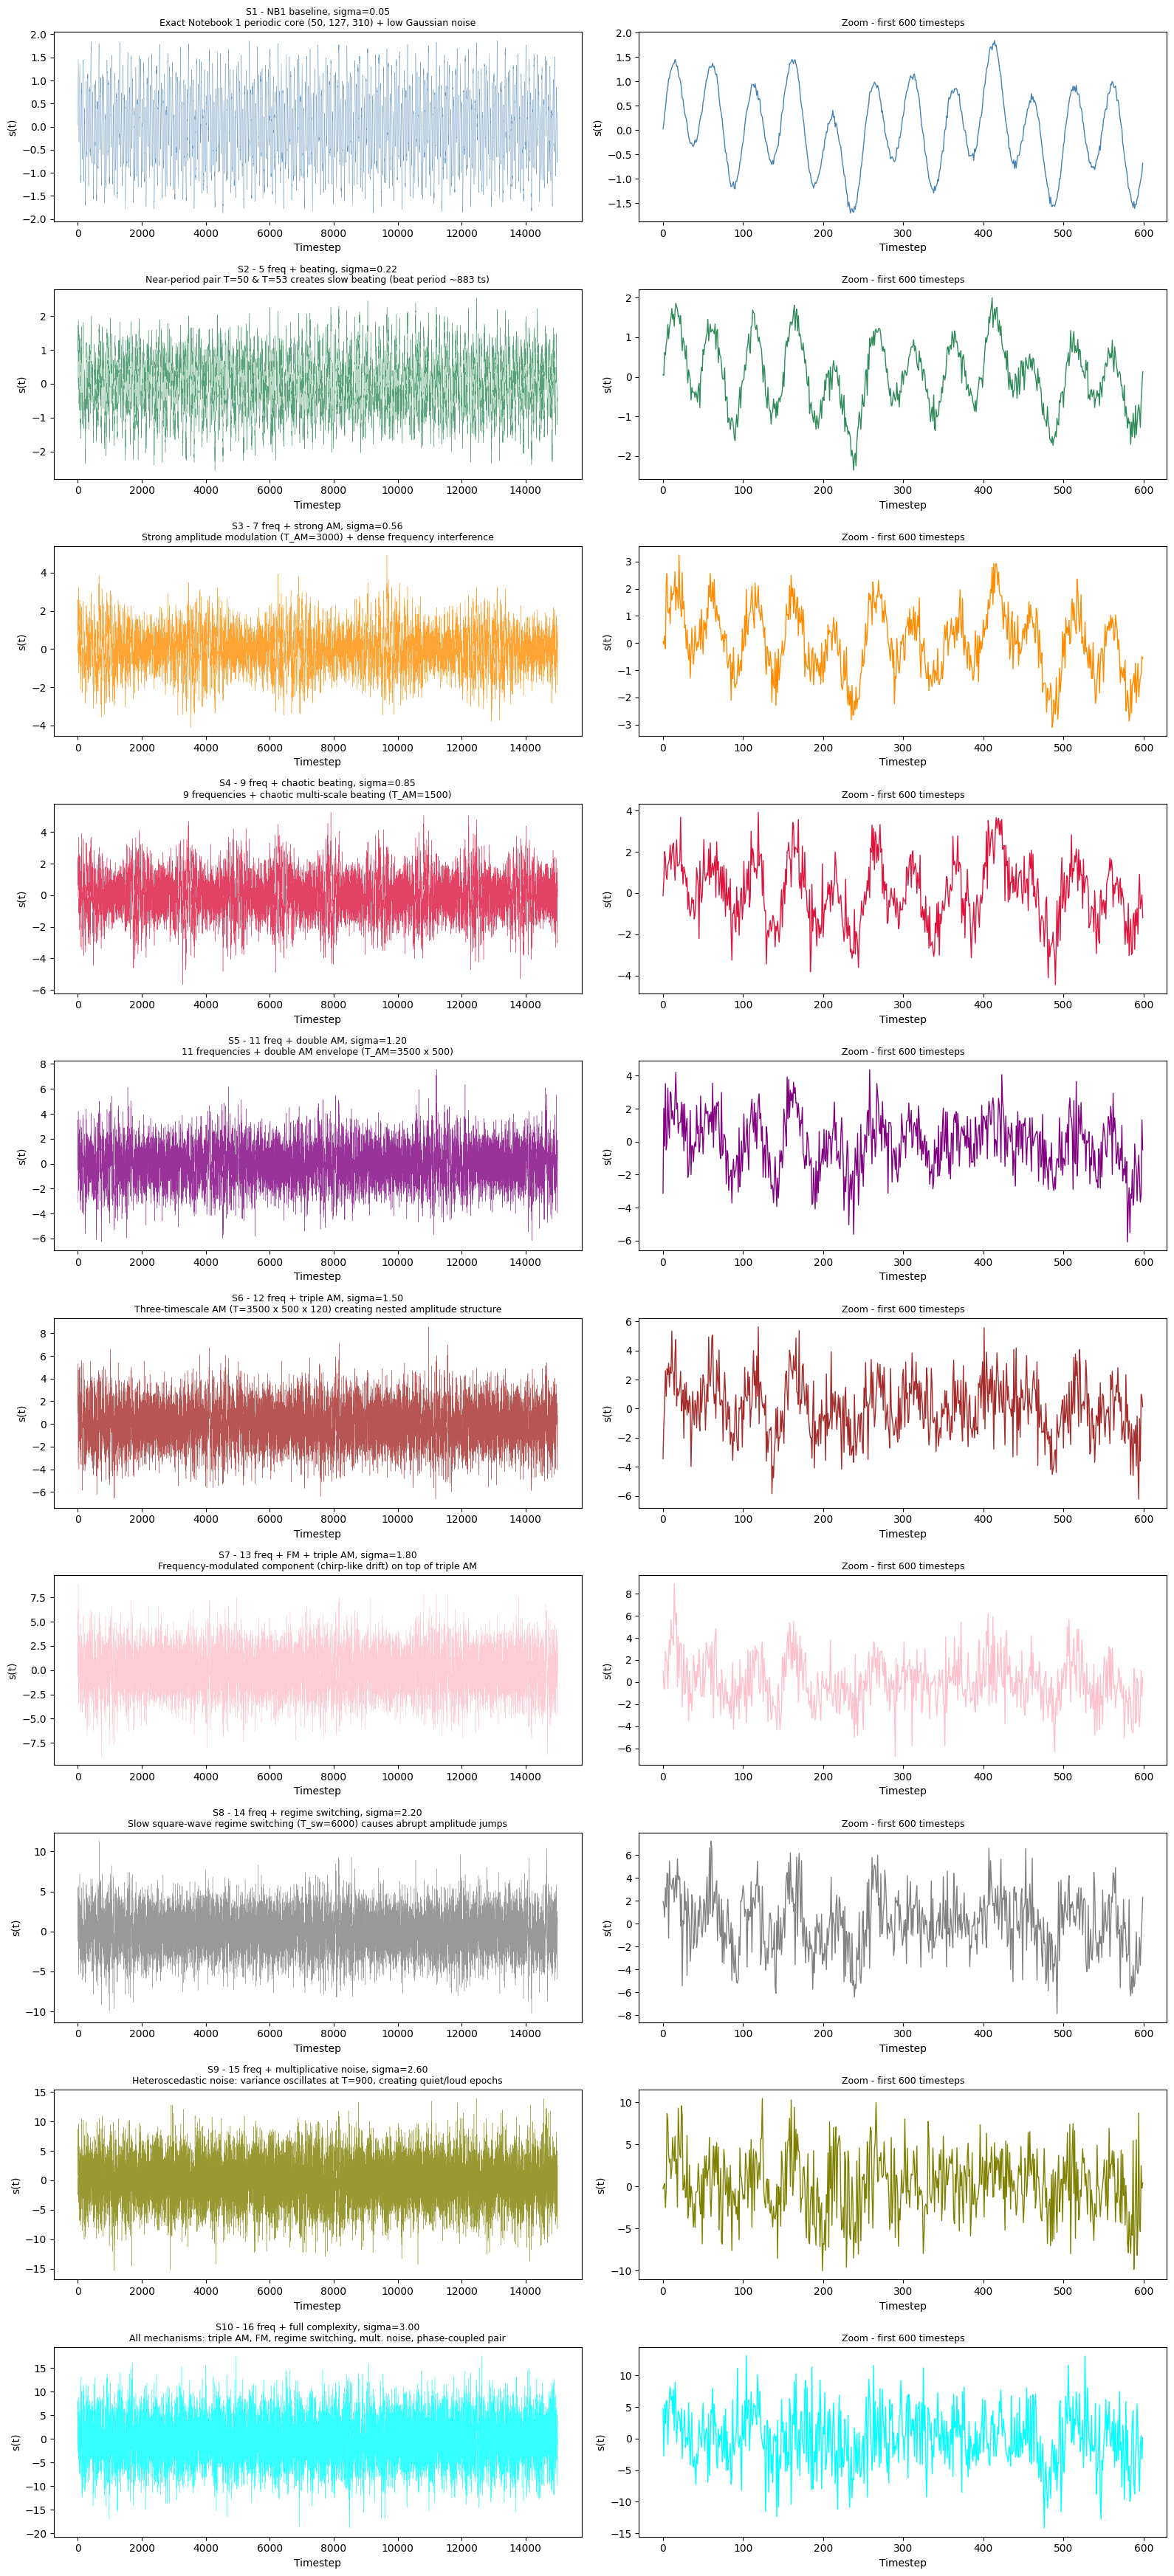

Figure saved -> single_hp_outputs_3/signals_overview.png


In [5]:
# ---------------------------------------------------------------------------
# Visualise all signals - full view + zoom
# ---------------------------------------------------------------------------
n_signals = len(SIGNALS)
fig, axes = plt.subplots(n_signals, 2, figsize=(16, 3.5 * n_signals))

colors = ["steelblue", "seagreen", "darkorange", "crimson",
          "purple", "brown", "pink", "gray", "olive", "cyan"]
for row, (name, cfg) in enumerate(SIGNALS.items()):
    sig   = cfg["data"]
    color = colors[row % len(colors)]
    label = cfg["label"]

    # Full signal
    ax = axes[row, 0]
    ax.plot(t_axis, sig, lw=0.3, color=color, alpha=0.8)
    ax.set_title(f"{label}\n{cfg['desc']}", fontsize=9)
    ax.set_xlabel("Timestep"); ax.set_ylabel("s(t)")

    # Zoom
    ax = axes[row, 1]
    ax.plot(t_axis[:600], sig[:600], lw=1.0, color=color)
    ax.set_title(f"Zoom - first 600 timesteps", fontsize=9)
    ax.set_xlabel("Timestep"); ax.set_ylabel("s(t)")

plt.tight_layout()
plt.savefig("single_hp_outputs_3/signals_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved -> single_hp_outputs_3/signals_overview.png")

## 3. ESN Configuration & Helper Functions

Section 3.2 uses the same refined Phase-A ESN grid as Notebook 1. For the
structural studies we also align the candidate ranges with Notebook 1:

| Architecture | Parameter(s) | Values |
|-------------|--------------|--------|
| ER | `p` | `[0, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1.0]` |
| WS | joint `(k, p_rewire)` grid | `k` in `[2, 4, 8, 16, 32, 64, N/2, N-1]`, `p_rewire` in `[0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]` |
| BA | `m` | powers of two up to `N-1` |


### 3.1 Helper Functions

- `build_dataset(signal, lag)` builds the lag-input supervised dataset
- `make_reservoir_matrix(...)` constructs a reproducible topology-specific `W`
- `load_notebook1_s1_reference()` reads the saved Notebook 1 `S1` references if available
- `run_topology_shs(...)` performs a temporal CV sweep over one topology parameter
- `run_ws_heatmap(...)` evaluates the full Watts-Strogatz `(k, p_rewire)` grid
- `summarise_ws_heatmap(...)` aggregates the WS grid and extracts the best pair
- `best_setting(df, param_name)` returns the parameter value with lowest mean RMSE
- `plot_single_hp(...)` draws the ER/BA single-parameter sensitivity plots
- `plot_ws_heatmap(...)` renders the WS joint sensitivity heatmap
- `run_signal_study(...)` orchestrates the full 3-architecture study for one signal
- `plot_esn_prediction(...)` trains on 75% / tests on 25%, returns predictions + metrics


In [ ]:
# ===========================================================================
# Helper functions
# ===========================================================================

def build_dataset(signal, lag=LAG):
    """Build supervised lag-input dataset from a 1-D time series."""
    t_sig = len(signal)
    X = np.column_stack([signal[i : t_sig - lag + i] for i in range(lag)])
    y = signal[lag:].reshape(-1, 1)
    return X, y

def make_reservoir_matrix(N, topology, topo_params):
    """Build a reproducible reservoir matrix."""
    rng = np.random.RandomState()

    if topology == "random":
        G = nx.erdos_renyi_graph(N, topo_params["p"], directed=True)
    elif topology == "small_world":
        k = int(topo_params["k"])
        if k % 2 != 0:
            k += 1
        k = min(max(k, 2), N - 1)
        G = nx.watts_strogatz_graph(N, k, p=topo_params["p_rewire"]).to_directed()
    elif topology == "scale_free":
        m = min(max(1, int(topo_params["m"])), N - 1)
        G = nx.barabasi_albert_graph(N, m).to_directed()
    else:
        raise ValueError(f"Unknown topology: {topology}")

    A = nx.adjacency_matrix(G).toarray().astype(np.float64)
    mask = A > 0
    W = np.zeros_like(A)
    W[mask] = rng.randn(mask.sum())

    if mask.any():
        eigs = np.linalg.eigvals(W)
        sr_natural = float(np.max(np.abs(eigs)))
    else:
        sr_natural = 0.0


    info = {
        "topology": topology,
        "N": N,
        "actual_density": mask.sum() / (N * N),
        "avg_degree": float(mask.sum(axis=1).mean()),
        "spectral_radius_natural": sr_natural,
        "n_edges": int(mask.sum()),
    }
    return W, info

def run_hp_search(signal_data, hp_configs, n_splits=N_SPLITS):
    """Notebook-1-style ESN hyperparameter search on a single signal."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    X, y = build_dataset(signal_data, lag=LAG)
    records = []

    for cfg_idx, cfg in enumerate(hp_configs):
        N, sr, lr, ridge, washout = (
            int(cfg["N"]), cfg["sr"], cfg["lr"], cfg["ridge"], int(cfg["washout"])
        )
        fold_rmses = []

        for train_idx, test_idx in tscv.split(X):
            X_tr_f, y_tr_f = X[train_idx], y[train_idx]
            X_te_f, y_te_f = X[test_idx], y[test_idx]

            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr_f)
            X_te = scaler.transform(X_te_f)

            try:
                reservoir = Reservoir(units=N, sr=sr, lr=lr)
                model = reservoir >> Ridge(ridge=ridge)
                model.fit(X_tr, y_tr_f, warmup=washout)
                y_pred = np.array(model.run(X_te)).reshape(-1)
                fold_rmses.append(np.sqrt(mean_squared_error(y_te_f.ravel(), y_pred)))
            except Exception:
                fold_rmses.append(np.nan)

        mean_rmse = float(np.nanmean(fold_rmses)) if fold_rmses else np.nan
        records.append({**cfg, "mean_rmse": mean_rmse})

        if (cfg_idx + 1) % 20 == 0 or cfg_idx == 0:
            valid = [row["mean_rmse"] for row in records if not np.isnan(row["mean_rmse"])]
            best_so_far = min(valid) if valid else float("nan")
            print(f"    [{cfg_idx + 1:3d}/{len(hp_configs)}]  best RMSE so far: {best_so_far:.5f}")

    df = pd.DataFrame(records).dropna(subset=["mean_rmse"])
    best = df.loc[df["mean_rmse"].idxmin()].to_dict()
    return best

def resolve_ws_k_values(N, candidate_values):
    """Sanitise Watts-Strogatz k values for a given reservoir size."""
    valid = []
    for val in candidate_values:
        k = min(max(2, int(val)), N - 1)
        if k % 2 != 0:
            k = max(2, k - 1)
        if 2 <= k < N and k not in valid:
            valid.append(k)
    return sorted(valid)

def resolve_ba_m_values(N, candidate_values):
    """Sanitise Barabasi-Albert m values for a given reservoir size."""
    valid = sorted({min(max(1, int(m)), N - 1) for m in candidate_values})
    return [m for m in valid if 1 <= m < N]

def load_notebook1_s1_reference():
    """Load saved Notebook 1 S1 references for Phase A and canonical topologies."""
    ref = {"phase_a": None, "phase_a_rmse": None, "canonical": None}

    phase_path = Path("single_hp_outputs_1/refined_grid_results.csv")
    if phase_path.exists():
        df_phase = pd.read_csv(phase_path).sort_values("rmse_mean")
        if not df_phase.empty:
            best_phase = df_phase.iloc[0]
            ref["phase_a"] = {
                "N": int(best_phase["N"]),
                "sr": float(best_phase["sr"]),
                "lr": float(best_phase["lr"]),
                "ridge": float(best_phase["ridge"]),
                "washout": int(best_phase["washout"]),
            }
            ref["phase_a_rmse"] = float(best_phase["rmse_mean"])

    er_path = Path("single_hp_outputs_1/topo_random_p.csv")
    ws_path = Path("single_hp_outputs_1/ws_k_p_rewire_heatmap_summary.csv")
    ba_path = Path("single_hp_outputs_1/topo_scale_free_m.csv")

    if er_path.exists() and ws_path.exists() and ba_path.exists():
        df_er = pd.read_csv(er_path).dropna(subset=["rmse"])
        df_ws = pd.read_csv(ws_path).sort_values("rmse_mean")
        df_ba = pd.read_csv(ba_path).dropna(subset=["rmse"])

        if not df_er.empty and not df_ws.empty and not df_ba.empty:
            ref["canonical"] = {
                "ER_p": float(df_er.groupby("p")["rmse"].mean().idxmin()),
                "WS_k": int(df_ws.iloc[0]["k"]),
                "WS_p_rewire": float(df_ws.iloc[0]["p_rewire"]),
                "BA_m": int(df_ba.groupby("m")["rmse"].mean().idxmin()),
            }

    return ref

def run_topology_shs(topology, param_name, param_values, esn_params, n_splits=N_SPLITS):
    """Single Hyperparameter Study over one structural topology parameter."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    records = []
    print(
        f"    [{topology}] sweep '{param_name}': "
        f"{len(param_values)} values x {n_splits} folds = {len(param_values) * n_splits} evals"
    )

    for val in param_values:
        topo_params = {param_name: val}
        try:
            W, info = make_reservoir_matrix(esn_params["N"], topology, topo_params)
        except Exception as exc:
            print(f"      [MATRIX ERROR] {param_name}={val}: {exc}")
            for fi in range(n_splits):
                records.append({
                    param_name: val,
                    "fold": fi,
                    "rmse": np.nan,
                    "mae": np.nan,
                    "r2": np.nan,
                    "density": np.nan,
                    "sr_natural": np.nan,
                    "train_time_s": np.nan,
                })
            continue

        for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
            X_tr_f, y_tr_f = X_all[train_idx], y_all[train_idx]
            X_te_f, y_te_f = X_all[test_idx], y_all[test_idx]

            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr_f)
            X_te = scaler.transform(X_te_f)

            try:
                t0 = time.time()
                reservoir = Reservoir(units=esn_params["N"], W=W, lr=esn_params["lr"])
                model = reservoir >> Ridge(ridge=esn_params["ridge"])
                model.fit(X_tr, y_tr_f, warmup=int(esn_params["washout"]))
                y_pred = np.array(model.run(X_te)).reshape(-1)
                y_true = y_te_f.ravel()
                records.append({
                    param_name: val,
                    "fold": fold_idx,
                    "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
                    "mae": mean_absolute_error(y_true, y_pred),
                    "r2": r2_score(y_true, y_pred),
                    "density": info["actual_density"],
                    "sr_natural": info["spectral_radius_natural"],
                    "train_time_s": time.time() - t0,
                })
            except Exception as exc:
                print(f"      [ERROR] {param_name}={val}, fold {fold_idx}: {exc}")
                records.append({
                    param_name: val,
                    "fold": fold_idx,
                    "rmse": np.nan,
                    "mae": np.nan,
                    "r2": np.nan,
                    "density": np.nan,
                    "sr_natural": np.nan,
                    "train_time_s": np.nan,
                })

    return pd.DataFrame(records)

def run_ws_heatmap(k_values, p_rewire_values, esn_params, n_splits=N_SPLITS):
    """Evaluate the full Watts-Strogatz (k, p_rewire) grid."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    records = []
    n_cfg = len(k_values) * len(p_rewire_values)
    print(
        "    [small_world] joint grid on (k, p_rewire): "
        f"{len(k_values)} x {len(p_rewire_values)} values x {n_splits} folds = {n_cfg * n_splits} evals"
    )

    for k in k_values:
        for p_rewire in p_rewire_values:
            try:
                W, info = make_reservoir_matrix(esn_params["N"], "small_world", {"k": k, "p_rewire": p_rewire})
            except Exception as exc:
                print(f"      [MATRIX ERROR] k={k}, p_rewire={p_rewire}: {exc}")
                for fi in range(n_splits):
                    records.append({
                        "k": k,
                        "p_rewire": p_rewire,
                        "fold": fi,
                        "rmse": np.nan,
                        "mae": np.nan,
                        "r2": np.nan,
                        "density": np.nan,
                        "sr_natural": np.nan,
                        "train_time_s": np.nan,
                    })
                continue

            for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
                X_tr_f, y_tr_f = X_all[train_idx], y_all[train_idx]
                X_te_f, y_te_f = X_all[test_idx], y_all[test_idx]

                scaler = StandardScaler()
                X_tr = scaler.fit_transform(X_tr_f)
                X_te = scaler.transform(X_te_f)

                try:
                    t0 = time.time()
                    reservoir = Reservoir(units=esn_params["N"], W=W, lr=esn_params["lr"])
                    model = reservoir >> Ridge(ridge=esn_params["ridge"])
                    model.fit(X_tr, y_tr_f, warmup=int(esn_params["washout"]))
                    y_pred = np.array(model.run(X_te)).reshape(-1)
                    y_true = y_te_f.ravel()
                    records.append({
                        "k": k,
                        "p_rewire": p_rewire,
                        "fold": fold_idx,
                        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
                        "mae": mean_absolute_error(y_true, y_pred),
                        "r2": r2_score(y_true, y_pred),
                        "density": info["actual_density"],
                        "sr_natural": info["spectral_radius_natural"],
                        "train_time_s": time.time() - t0,
                    })
                except Exception as exc:
                    print(f"      [ERROR] k={k}, p_rewire={p_rewire}, fold {fold_idx}: {exc}")
                    records.append({
                        "k": k,
                        "p_rewire": p_rewire,
                        "fold": fold_idx,
                        "rmse": np.nan,
                        "mae": np.nan,
                        "r2": np.nan,
                        "density": np.nan,
                        "sr_natural": np.nan,
                        "train_time_s": np.nan,
                    })

    return pd.DataFrame(records)

def summarise_ws_heatmap(df_ws_grid):
    """Aggregate the WS grid and extract the best (k, p_rewire) pair."""
    ws_summary = (
        df_ws_grid.dropna(subset=["rmse"])
        .groupby(["k", "p_rewire"])
        .agg(
            rmse_mean=("rmse", "mean"),
            rmse_std=("rmse", "std"),
            r2_mean=("r2", "mean"),
            density_mean=("density", "mean"),
            sr_natural_mean=("sr_natural", "mean"),
        )
        .reset_index()
        .sort_values("rmse_mean")
    )
    best_row = ws_summary.iloc[0]
    return ws_summary, best_row

def best_setting(df, param_name):
    """Return the parameter value with the lowest mean RMSE across folds."""
    agg = df.dropna(subset=["rmse"]).groupby(param_name)["rmse"].mean()
    return agg.idxmin()

def plot_single_hp(df, hp_name, hp_values, label_map=None, title="", palette="colorblind", save_path=None):
    """Three-panel SHS plot: RMSE distribution, mean +/- std, and R^2 distribution."""
    labels = [label_map[v] if label_map else str(v) for v in hp_values]
    df_plt = df.dropna(subset=["rmse"]).copy()
    lbl_map = dict(zip(hp_values, labels))
    df_plt["_lbl"] = df_plt[hp_name].map(lbl_map)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    if title:
        fig.suptitle(title, fontsize=11, fontweight="bold", y=1.01)

    ax = axes[0]
    sns.boxplot(data=df_plt, x="_lbl", y="rmse", order=labels, palette=palette, width=0.5, fliersize=0, ax=ax)
    sns.stripplot(data=df_plt, x="_lbl", y="rmse", order=labels, color="black", size=4, alpha=0.6, jitter=True, ax=ax)
    ax.set_xlabel(hp_name)
    ax.set_ylabel("RMSE")
    ax.set_title("RMSE - fold distribution")
    ax.tick_params(axis="x", rotation=45)

    ax = axes[1]
    summ = (
        df_plt.groupby("_lbl")["rmse"]
        .agg(["mean", "std"])
        .reindex(labels)
        .reset_index()
    )
    ax.errorbar(
        summ["_lbl"], summ["mean"], yerr=summ["std"], marker="o", capsize=6,
        linewidth=2, markersize=8, color="steelblue", elinewidth=1.5
    )
    ax.set_xlabel(hp_name)
    ax.set_ylabel("Mean RMSE +/- std")
    ax.set_title("Mean RMSE +/- std across folds")
    ax.tick_params(axis="x", rotation=45)

    ax = axes[2]
    sns.boxplot(data=df_plt, x="_lbl", y="r2", order=labels, palette=palette, width=0.5, fliersize=0, ax=ax)
    sns.stripplot(data=df_plt, x="_lbl", y="r2", order=labels, color="black", size=4, alpha=0.6, jitter=True, ax=ax)
    ax.set_xlabel(hp_name)
    ax.set_ylabel("R^2")
    ax.set_title("R^2 - fold distribution")
    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
        print(f"    Figure saved -> {save_path}")
    plt.show()

def plot_ws_heatmap(ws_summary, title="", save_path=None, ax=None, show=True):
    """Render the WS joint sensitivity heatmap with mean +/- std annotations."""
    ws_rmse_pivot = ws_summary.pivot(index="k", columns="p_rewire", values="rmse_mean")
    ws_std_pivot = (
        ws_summary.pivot(index="k", columns="p_rewire", values="rmse_std")
        .reindex(index=ws_rmse_pivot.index, columns=ws_rmse_pivot.columns)
        .fillna(0.0)
    )
    ws_annotations = ws_rmse_pivot.copy().astype(object)
    for k in ws_rmse_pivot.index:
        for p_rewire in ws_rmse_pivot.columns:
            mean_val = ws_rmse_pivot.loc[k, p_rewire]
            std_val = ws_std_pivot.loc[k, p_rewire]
            ws_annotations.loc[k, p_rewire] = f"{mean_val:.3f}\n+/-{std_val:.3f}"

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure

    sns.heatmap(
        ws_rmse_pivot,
        annot=ws_annotations,
        fmt="",
        annot_kws={"fontsize": 7},
        cmap="viridis_r",
        linewidths=0.5,
        cbar=own_fig,
        cbar_kws={"label": "Mean CV RMSE"} if own_fig else None,
        ax=ax,
    )
    ax.set_xlabel("p_rewire")
    ax.set_ylabel("k (ring neighbours)")
    if title:
        ax.set_title(title, fontsize=10, fontweight="bold")

    if own_fig:
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=140, bbox_inches="tight")
            print(f"    Figure saved -> {save_path}")
        if show:
            plt.show()

    return ax

def plot_esn_prediction(sig_name, sig_cfg, esn_params, topo, topo_params, test_frac=0.25, zoom=400, ax_row=None):
    """Train on the first part of the signal and plot the held-out prediction."""
    signal = sig_cfg["data"]
    X_sig, y_sig = build_dataset(signal, lag=LAG)
    n = len(X_sig)
    n_train = int(n * (1 - test_frac))

    X_train, y_train = X_sig[:n_train], y_sig[:n_train]
    X_test, y_test = X_sig[n_train:], y_sig[n_train:]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train)
    X_te = scaler.transform(X_test)

    W, _ = make_reservoir_matrix(esn_params["N"], topo, topo_params)
    reservoir = Reservoir(units=esn_params["N"], W=W, lr=esn_params["lr"])
    model = reservoir >> Ridge(ridge=esn_params["ridge"])
    model.fit(X_tr, y_train, warmup=int(esn_params["washout"]))
    y_pred = np.array(model.run(X_te)).reshape(-1)
    y_true = y_test.ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    t_all = np.arange(len(signal))
    t_test = t_all[LAG + n_train:]

    own_fig = ax_row is None
    if own_fig:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    else:
        axes = ax_row

    ax = axes[0]
    ax.plot(t_all[:LAG + n_train], signal[:LAG + n_train], lw=0.25, color="lightgray", label="Training signal")
    ax.plot(t_test, y_true, lw=0.8, color="steelblue", label="Real (test)")
    ax.plot(t_test, y_pred, lw=0.8, color="tomato", alpha=0.85, label="Predicted")
    ax.axvline(LAG + n_train, color="black", ls="--", lw=0.8)
    ax.set_title(f"{sig_name}   RMSE={rmse:.4f}   R^2={r2:.4f}", fontsize=9)
    ax.set_xlabel("Timestep")
    ax.set_ylabel("s(t)")
    ax.legend(loc="upper left", fontsize=7)

    ax = axes[1]
    ax.plot(t_test[:zoom], y_true[:zoom], lw=1.2, color="steelblue", label="Real")
    ax.plot(t_test[:zoom], y_pred[:zoom], lw=1.2, color="tomato", ls="--", label="Predicted")
    ax.set_title(f"Zoom - first {zoom} test timesteps", fontsize=9)
    ax.set_xlabel("Timestep")
    ax.set_ylabel("s(t)")
    ax.legend(fontsize=7)

    if own_fig:
        plt.tight_layout()
        plt.show()

    return y_true, y_pred, rmse, r2


def run_signal_study(sig_name, sig_cfg, esn_params, er_p_values, ws_k_values, ws_prw_values, ba_m_values, output_dir="single_hp_outputs_3"):
    """Full topology study for one signal at its own best ESN parameters."""
    global X_all, y_all
    signal = sig_cfg["data"]
    X_all, y_all = build_dataset(signal, lag=LAG)

    ws_k_values_valid = resolve_ws_k_values(esn_params["N"], ws_k_values)
    ba_m_values_valid = resolve_ba_m_values(esn_params["N"], ba_m_values)

    print(f"\n{'=' * 62}")
    print(f"  {sig_cfg['label']}")
    print(f"  {sig_cfg['desc']}")
    print(f"  Dataset: X={X_all.shape}  y={y_all.shape}")
    print(f"  ESN params: {esn_params}")
    print(f"{'=' * 62}")
    t_start = time.time()

    print("\n[ER] Sweeping connection probability p ...")
    df_er = run_topology_shs("random", "p", er_p_values, esn_params)
    df_er.to_csv(f"{output_dir}/shs_{sig_name}_er_p.csv", index=False)

    print("\n[WS] Joint sweep on (k, p_rewire) ...")
    df_ws_grid = run_ws_heatmap(ws_k_values_valid, ws_prw_values, esn_params)
    df_ws_grid.to_csv(f"{output_dir}/shs_{sig_name}_ws_grid.csv", index=False)
    ws_summary, best_ws_row = summarise_ws_heatmap(df_ws_grid)
    ws_summary.to_csv(f"{output_dir}/shs_{sig_name}_ws_heatmap_summary.csv", index=False)

    print("\n[BA] Sweeping edges-per-new-node m ...")
    df_ba = run_topology_shs("scale_free", "m", ba_m_values_valid, esn_params)
    df_ba.to_csv(f"{output_dir}/shs_{sig_name}_ba_m.csv", index=False)

    best_er_p = best_setting(df_er, "p")
    rmse_er = float(df_er[df_er["p"] == best_er_p]["rmse"].mean())

    best_ws_k = int(best_ws_row["k"])
    best_ws_prw = float(best_ws_row["p_rewire"])
    rmse_ws = float(best_ws_row["rmse_mean"])
    std_ws = float(best_ws_row["rmse_std"] if not np.isnan(best_ws_row["rmse_std"]) else 0.0)

    best_ba_m = best_setting(df_ba, "m")
    rmse_ba = float(df_ba[df_ba["m"] == best_ba_m]["rmse"].mean())

    elapsed = time.time() - t_start
    print(f"\n{'-' * 62}")
    print(f"  Best ER  : p={best_er_p:g}              -> mean RMSE = {rmse_er:.5f}")
    print(f"  Best WS  : k={best_ws_k}, p_rewire={best_ws_prw:g} -> mean RMSE = {rmse_ws:.5f} +/- {std_ws:.5f}")
    print(f"  Best BA  : m={best_ba_m}               -> mean RMSE = {rmse_ba:.5f}")
    print(f"  Elapsed  : {elapsed / 60:.1f} min")

    return {
        "label": sig_cfg["label"],
        "n_components": sig_cfg["n_components"],
        "noise_std": sig_cfg["noise_std"],
        "extra": sig_cfg["extra"],
        "esn_params": dict(esn_params),
        "ER": {"df": df_er, "best_p": float(best_er_p), "best_rmse": rmse_er},
        "WS": {
            "df": df_ws_grid,
            "summary": ws_summary,
            "best_k": best_ws_k,
            "best_prw": best_ws_prw,
            "best_rmse": rmse_ws,
            "best_std": std_ws,
        },
        "BA": {"df": df_ba, "best_m": int(best_ba_m), "best_rmse": rmse_ba},
    }

print("All helper functions defined.")


All helper functions defined.


In [6]:
# Container for all study results - populated as we run each signal below
study_results = {}

### 3.2 Per-Signal ESN Hyperparameter Optimisation

Before studying topology effects, we tune the core ESN hyperparameters
`(N, sr, lr, ridge, washout)` independently for **all ten signals** using the
same refined Phase-A grid used in Notebook 1 and the same **10-fold temporal CV**
protocol.

`S1` now reuses the exact Notebook 1 periodic core `(50, 127, 310)`. In addition,
if the saved Notebook 1 refined-grid results are available in `single_hp_outputs_1`,
we adopt that `S1` reference downstream so that the comparisons remain coherent
across notebooks.


In [7]:
# ---------------------------------------------------------------------------
# Per-signal Phase-A optimisation on the first ten signals
# ---------------------------------------------------------------------------
HP_GRID = {
    "N":       [25, 50, 100, 300, 400],
    "sr":      [0.9, 1.1, 1.3],
    "lr":      [0.05, 0.1, 0.2],
    "ridge":   [1e-3, 1e-2, 5e-2],
    "washout": [10],
}
HP_CONFIGS = list(ParameterGrid(HP_GRID))
PHASE_A_SIGNAL_NAMES = SIGNAL_ORDER

print(
    f"Phase-A grid: {len(HP_CONFIGS)} configs x {N_SPLITS} folds x "
    f"{len(PHASE_A_SIGNAL_NAMES)} signals = {len(HP_CONFIGS) * N_SPLITS * len(PHASE_A_SIGNAL_NAMES)} total evals\n"
)

BEST_PARAMS_SEARCH_PER_SIGNAL = {}
BEST_PARAMS_PER_SIGNAL = {}
_hp_best_rmse = {}

for sig_name in PHASE_A_SIGNAL_NAMES:
    print(f"\n{'=' * 55}")
    print(f"  HP search for {sig_name}: {SIGNALS[sig_name]['label']}")
    print(f"{'=' * 55}")

    best = run_hp_search(SIGNALS[sig_name]["data"], HP_CONFIGS)
    params = {
        "N": int(best["N"]),
        "sr": float(best["sr"]),
        "lr": float(best["lr"]),
        "ridge": float(best["ridge"]),
        "washout": int(best["washout"]),
    }
    BEST_PARAMS_SEARCH_PER_SIGNAL[sig_name] = params
    BEST_PARAMS_PER_SIGNAL[sig_name] = dict(params)
    _hp_best_rmse[sig_name] = float(best["mean_rmse"])

    print(f"  -> Grid-search best: {params}  (CV RMSE={best['mean_rmse']:.5f})")

NOTEBOOK1_REFERENCE = load_notebook1_s1_reference()
NOTEBOOK1_S1_REFERENCE = NOTEBOOK1_REFERENCE["phase_a"]
NOTEBOOK1_S1_CANONICAL = NOTEBOOK1_REFERENCE["canonical"]

s1_source = "Notebook 3 per-signal grid search"
s1_search = BEST_PARAMS_SEARCH_PER_SIGNAL["S1"]
s1_match = False
if NOTEBOOK1_S1_REFERENCE is not None:
    notebook1_rmse = NOTEBOOK1_REFERENCE["phase_a_rmse"]
    local_rmse = _hp_best_rmse["S1"]
    if s1_match or notebook1_rmse <= local_rmse + 1e-12:
        BEST_PARAMS_PER_SIGNAL["S1"] = dict(NOTEBOOK1_S1_REFERENCE)
        s1_source = "Notebook 1 refined reference"
    else:
        print(
            "[WARN] Notebook 1 S1 reference differs from the local grid-search optimum; "
            "keeping the Notebook 3 search result downstream."
        )

best_param_rows = []
for sig_name in PHASE_A_SIGNAL_NAMES:
    p = BEST_PARAMS_PER_SIGNAL[sig_name]
    best_param_rows.append({
        "Signal": sig_name,
        "N": p["N"],
        "sr": p["sr"],
        "lr": p["lr"],
        "ridge": p["ridge"],
        "washout": p["washout"],
        "search_CV_RMSE": _hp_best_rmse[sig_name],
        "source": s1_source if sig_name == "S1" else "Notebook 3 per-signal grid search",
    })

df_best_params = pd.DataFrame(best_param_rows)
df_best_params.to_csv("single_hp_outputs_3/best_params_per_signal.csv", index=False)

print(f"\n{'=' * 96}")
print(
    df_best_params.to_string(
        index=False,
        formatters={
            "sr": "{:.2f}".format,
            "lr": "{:.2f}".format,
            "ridge": "{:.0e}".format,
            "search_CV_RMSE": "{:.5f}".format,
        },
    )
)
print(f"{'=' * 96}")
print("\nSaved -> single_hp_outputs_3/best_params_per_signal.csv")

s1_search = BEST_PARAMS_SEARCH_PER_SIGNAL["S1"]
print("\nS1 consistency check against Notebook 1")
print(f"  Shared periodic core      : periods={BASELINE_PERIODS}, noise sigma=0.05")
print(f"  Notebook 3 grid-search S1: {s1_search}  (CV RMSE={_hp_best_rmse['S1']:.5f})")

if NOTEBOOK1_S1_REFERENCE is not None:
    print(f"  Notebook 1 reference      : {NOTEBOOK1_S1_REFERENCE}  (CV RMSE={NOTEBOOK1_REFERENCE['phase_a_rmse']:.5f})")
    print(f"  Exact parameter match     : {s1_match}")
    print(f"  Downstream S1 source      : {s1_source}")

    df_s1_consistency = pd.DataFrame([
        {
            "periods": "50,127,310",
            "noise_sigma": 0.05,
            "searched_N": s1_search["N"],
            "searched_sr": s1_search["sr"],
            "searched_lr": s1_search["lr"],
            "searched_ridge": s1_search["ridge"],
            "searched_washout": s1_search["washout"],
            "searched_rmse": _hp_best_rmse["S1"],
            "notebook1_N": NOTEBOOK1_S1_REFERENCE["N"],
            "notebook1_sr": NOTEBOOK1_S1_REFERENCE["sr"],
            "notebook1_lr": NOTEBOOK1_S1_REFERENCE["lr"],
            "notebook1_ridge": NOTEBOOK1_S1_REFERENCE["ridge"],
            "notebook1_washout": NOTEBOOK1_S1_REFERENCE["washout"],
            "notebook1_rmse": NOTEBOOK1_REFERENCE["phase_a_rmse"],
            "downstream_source": s1_source,
            "exact_match": bool(s1_match),
        }
    ])
    df_s1_consistency.to_csv("single_hp_outputs_3/s1_consistency_check.csv", index=False)
    print("  Saved -> single_hp_outputs_3/s1_consistency_check.csv")
else:
    print("  Notebook 1 refined-grid CSV not found; downstream S1 uses the local grid-search result.")


Phase-A grid: 135 configs x 10 folds x 10 signals = 13500 total evals


  HP search for S1: S1 - NB1 baseline, sigma=0.05
    [  1/135]  best RMSE so far: 0.08771
    [ 20/135]  best RMSE so far: 0.07309
    [ 40/135]  best RMSE so far: 0.05975
    [ 60/135]  best RMSE so far: 0.05656
    [ 80/135]  best RMSE so far: 0.05656
    [100/135]  best RMSE so far: 0.05454
    [120/135]  best RMSE so far: 0.05417
  -> Grid-search best: {'N': 400, 'sr': 1.1, 'lr': 0.05, 'ridge': 0.01, 'washout': 10}  (CV RMSE=0.05417)

  HP search for S2: S2 - 5 freq + beating, sigma=0.22
    [  1/135]  best RMSE so far: 0.27133
    [ 20/135]  best RMSE so far: 0.26324
    [ 40/135]  best RMSE so far: 0.25402
    [ 60/135]  best RMSE so far: 0.25098
    [ 80/135]  best RMSE so far: 0.25077
    [100/135]  best RMSE so far: 0.25024
    [120/135]  best RMSE so far: 0.25017
  -> Grid-search best: {'N': 400, 'sr': 0.9, 'lr': 0.05, 'ridge': 0.05, 'washout': 10}  (CV RMSE=0.25017)

  HP search for S3: S3 - 7 freq + st

### 3.3 Preliminary CV - Canonical Best Topology Parameters

Using the `S1` hyperparameters selected above, we sweep the structural parameters
on **Signal S1** to obtain canonical topology settings for the final comparison.
To match Notebook 1, ER uses the same fine-grained probability grid and WS is
studied through the full joint `(k, p_rewire)` heatmap instead of two separate
one-at-a-time sweeps.


  Preliminary CV on S1 - canonical topology search
  10-fold temporal CV, reservoir N=400
  ESN params: sr=1.1  lr=0.05
              ridge=0.01  washout=10

[ER] Sweeping p ...
    [random] sweep 'p': 9 values x 10 folds = 90 evals
    Figure saved -> single_hp_outputs_3/shs_S1_er_p.png


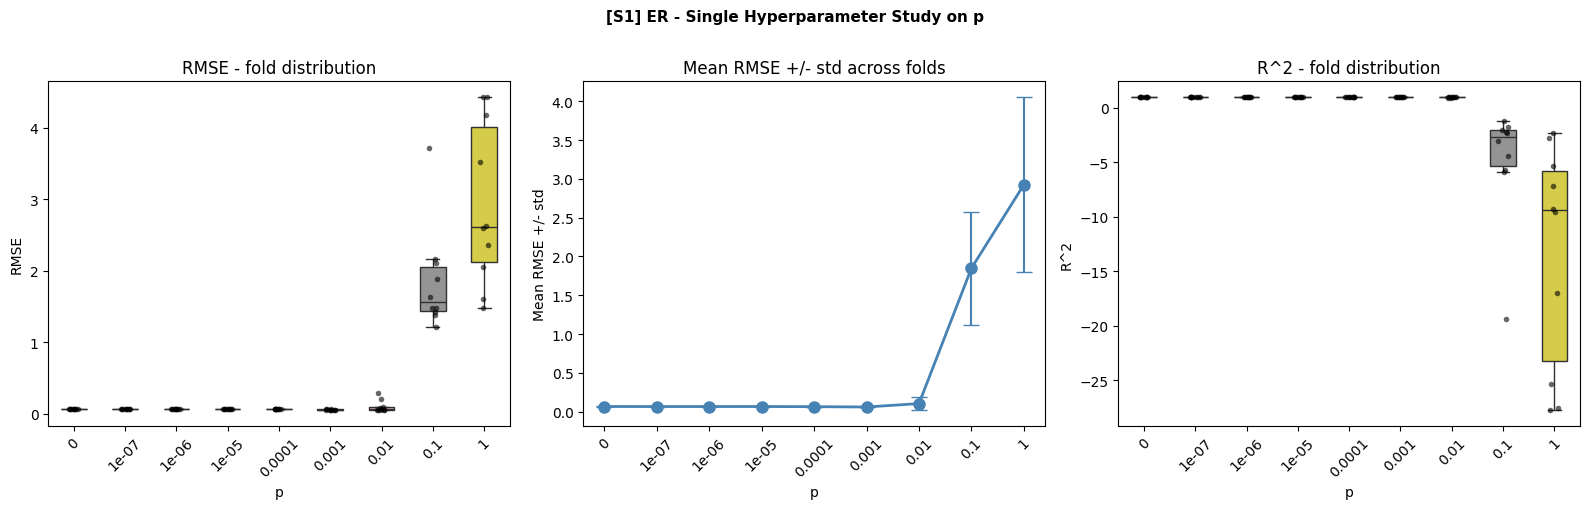


[WS] Joint sweep on (k, p_rewire) ...
    [small_world] joint grid on (k, p_rewire): 8 x 11 values x 10 folds = 880 evals
    Figure saved -> single_hp_outputs_3/shs_S1_ws_heatmap.png


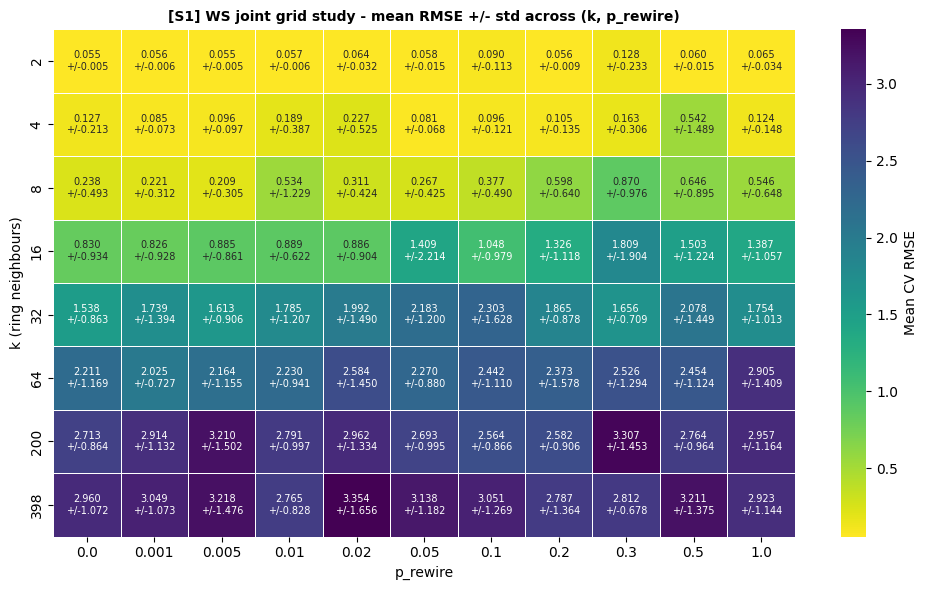


[BA] Sweeping m ...
    [scale_free] sweep 'm': 9 values x 10 folds = 90 evals
    Figure saved -> single_hp_outputs_3/shs_S1_ba_m.png


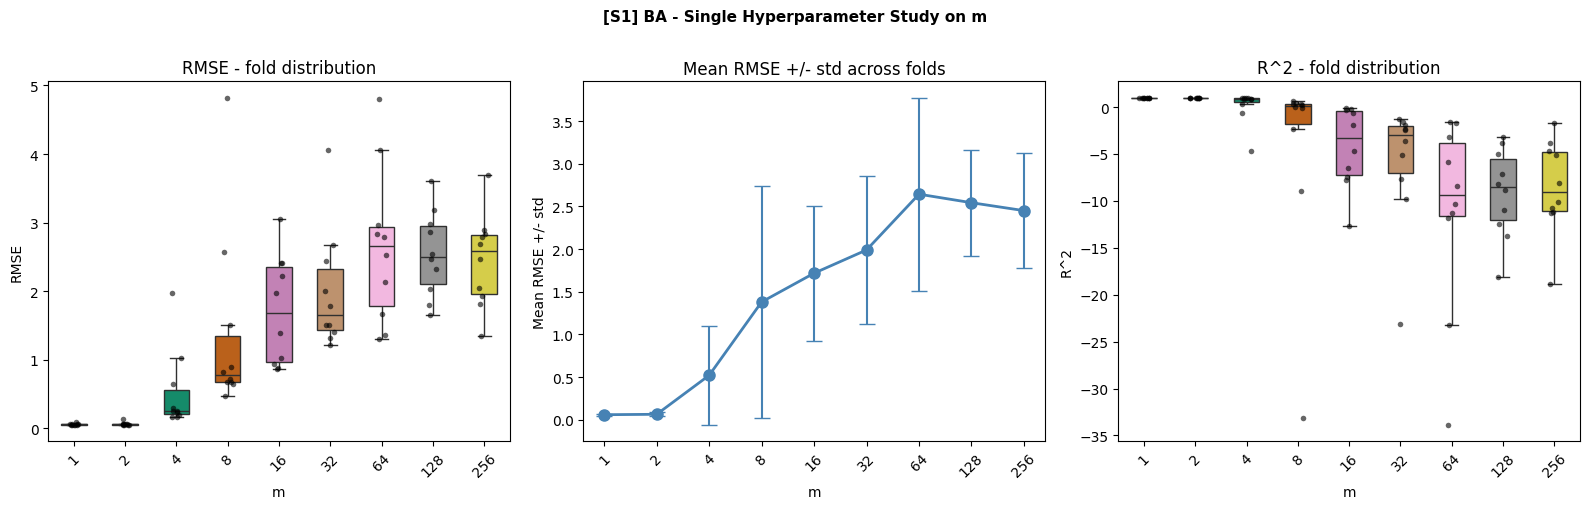


Saved -> single_hp_outputs_3/s1_canonical_comparison.csv
[WARN] Notebook 1 saved topology reference differs from the local S1 topology study; downstream comparisons keep the Notebook 3 local result.

--------------------------------------------------------------
  Local S1 topology study results:
    ER  : p        = 0.001
    WS  : k        = 2
    WS  : p_rewire = 0.005
    BA  : m        = 1

  Notebook 1 canonical reference:
    ER  : p        = 0.001
    WS  : k        = 2
    WS  : p_rewire = 1
    BA  : m        = 1

  Canonical topology source used downstream: Notebook 3 S1 topology study
--------------------------------------------------------------


In [8]:
# ---------------------------------------------------------------------------
# Preliminary Cross-Validation on S1 (aligned with Notebook 1)
# ---------------------------------------------------------------------------
BEST_PARAMS = BEST_PARAMS_PER_SIGNAL["S1"]
NOTEBOOK1_REFERENCE = load_notebook1_s1_reference()

N = BEST_PARAMS["N"]
ER_P_VALUES = [0, 1e-7, 1e-6, 1e-5, 1e-4, 0.001, 0.01, 0.1, 1.0]
WS_K_VALUES = resolve_ws_k_values(N, [2, 4, 8, 16, 32, 64, N // 2, N - 1])
WS_PRW_VALUES = [0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]

BA_M_VALUES = []
m_val = 1
while m_val < N:
    BA_M_VALUES.append(m_val)
    m_val *= 2

X_all, y_all = build_dataset(SIGNALS["S1"]["data"], lag=LAG)

print("=" * 62)
print("  Preliminary CV on S1 - canonical topology search")
print(f"  {N_SPLITS}-fold temporal CV, reservoir N={BEST_PARAMS['N']}")
print(f"  ESN params: sr={BEST_PARAMS['sr']}  lr={BEST_PARAMS['lr']}")
print(f"              ridge={BEST_PARAMS['ridge']}  washout={BEST_PARAMS['washout']}")
print("=" * 62)

print("\n[ER] Sweeping p ...")
df_shs_er = run_topology_shs("random", "p", ER_P_VALUES, BEST_PARAMS)
df_shs_er.to_csv("single_hp_outputs_3/shs_S1_er_p.csv", index=False)
er_labels = {p: f"{p:g}" for p in ER_P_VALUES}
plot_single_hp(
    df_shs_er,
    "p",
    ER_P_VALUES,
    label_map=er_labels,
    title="[S1] ER - Single Hyperparameter Study on p",
    save_path="single_hp_outputs_3/shs_S1_er_p.png",
)
CANONICAL_ER_P_LOCAL = float(best_setting(df_shs_er, "p"))

print("\n[WS] Joint sweep on (k, p_rewire) ...")
df_ws_grid = run_ws_heatmap(WS_K_VALUES, WS_PRW_VALUES, BEST_PARAMS)
df_ws_grid.to_csv("single_hp_outputs_3/shs_S1_ws_grid.csv", index=False)
ws_grid_summary, best_ws_row = summarise_ws_heatmap(df_ws_grid)
ws_grid_summary.to_csv("single_hp_outputs_3/shs_S1_ws_heatmap_summary.csv", index=False)
plot_ws_heatmap(
    ws_grid_summary,
    title="[S1] WS joint grid study - mean RMSE +/- std across (k, p_rewire)",
    save_path="single_hp_outputs_3/shs_S1_ws_heatmap.png",
)
CANONICAL_WS_K_LOCAL = int(best_ws_row["k"])
CANONICAL_WS_PRW_LOCAL = float(best_ws_row["p_rewire"])

print("\n[BA] Sweeping m ...")
df_shs_ba = run_topology_shs("scale_free", "m", BA_M_VALUES, BEST_PARAMS)
df_shs_ba.to_csv("single_hp_outputs_3/shs_S1_ba_m.csv", index=False)
ba_labels = {m: str(m) for m in BA_M_VALUES}
plot_single_hp(
    df_shs_ba,
    "m",
    BA_M_VALUES,
    label_map=ba_labels,
    title="[S1] BA - Single Hyperparameter Study on m",
    save_path="single_hp_outputs_3/shs_S1_ba_m.png",
)
CANONICAL_BA_M_LOCAL = int(best_setting(df_shs_ba, "m"))

NOTEBOOK1_S1_CANONICAL = NOTEBOOK1_REFERENCE["canonical"]
CANONICAL_ER_P = CANONICAL_ER_P_LOCAL
CANONICAL_WS_K = CANONICAL_WS_K_LOCAL
CANONICAL_WS_PRW = CANONICAL_WS_PRW_LOCAL
CANONICAL_BA_M = CANONICAL_BA_M_LOCAL
canonical_source = "Notebook 3 S1 topology study"

if NOTEBOOK1_S1_CANONICAL is not None:
    df_canonical_compare = pd.DataFrame([
        {
            "parameter": "ER_p",
            "local_notebook3": CANONICAL_ER_P_LOCAL,
            "notebook1_reference": NOTEBOOK1_S1_CANONICAL["ER_p"],
            "used_downstream": CANONICAL_ER_P,
            "exact_match": bool(np.isclose(CANONICAL_ER_P_LOCAL, NOTEBOOK1_S1_CANONICAL["ER_p"])),
        },
        {
            "parameter": "WS_k",
            "local_notebook3": CANONICAL_WS_K_LOCAL,
            "notebook1_reference": NOTEBOOK1_S1_CANONICAL["WS_k"],
            "used_downstream": CANONICAL_WS_K,
            "exact_match": bool(CANONICAL_WS_K_LOCAL == NOTEBOOK1_S1_CANONICAL["WS_k"]),
        },
        {
            "parameter": "WS_p_rewire",
            "local_notebook3": CANONICAL_WS_PRW_LOCAL,
            "notebook1_reference": NOTEBOOK1_S1_CANONICAL["WS_p_rewire"],
            "used_downstream": CANONICAL_WS_PRW,
            "exact_match": bool(np.isclose(CANONICAL_WS_PRW_LOCAL, NOTEBOOK1_S1_CANONICAL["WS_p_rewire"])),
        },
        {
            "parameter": "BA_m",
            "local_notebook3": CANONICAL_BA_M_LOCAL,
            "notebook1_reference": NOTEBOOK1_S1_CANONICAL["BA_m"],
            "used_downstream": CANONICAL_BA_M,
            "exact_match": bool(CANONICAL_BA_M_LOCAL == NOTEBOOK1_S1_CANONICAL["BA_m"]),
        },
    ])
    df_canonical_compare.to_csv("single_hp_outputs_3/s1_canonical_comparison.csv", index=False)
    print("\nSaved -> single_hp_outputs_3/s1_canonical_comparison.csv")
    if not bool(df_canonical_compare["exact_match"].all()):
        print(
            "[WARN] Notebook 1 saved topology reference differs from the local S1 topology study; "
            "downstream comparisons keep the Notebook 3 local result."
        )

print(f"\n{'-' * 62}")
print("  Local S1 topology study results:")
print(f"    ER  : p        = {CANONICAL_ER_P_LOCAL:g}")
print(f"    WS  : k        = {CANONICAL_WS_K_LOCAL}")
print(f"    WS  : p_rewire = {CANONICAL_WS_PRW_LOCAL:g}")
print(f"    BA  : m        = {CANONICAL_BA_M_LOCAL}")
if NOTEBOOK1_S1_CANONICAL is not None:
    print("\n  Notebook 1 canonical reference:")
    print(f"    ER  : p        = {NOTEBOOK1_S1_CANONICAL['ER_p']:g}")
    print(f"    WS  : k        = {NOTEBOOK1_S1_CANONICAL['WS_k']}")
    print(f"    WS  : p_rewire = {NOTEBOOK1_S1_CANONICAL['WS_p_rewire']:g}")
    print(f"    BA  : m        = {NOTEBOOK1_S1_CANONICAL['BA_m']}")
print(f"\n  Canonical topology source used downstream: {canonical_source}")
print(f"{'-' * 62}")


## 4. Topology Study - Signal S1
**Notebook 1 baseline: 3 incommensurate frequencies, sigma=0.05**. `S1` now
shares the same periodic core as Notebook 1 and the downstream canonical choices
are anchored to the saved Notebook 1 reference whenever those artifacts exist.

Expected behaviour: architecture differences should stay relatively small because
this is still the cleanest benchmark in the suite, but the ranking should now be
coherent with Notebook 1 and WS should be interpreted from the joint heatmap.


In [9]:
study_results["S1"] = run_signal_study(
    "S1", SIGNALS["S1"], BEST_PARAMS_PER_SIGNAL["S1"],
    ER_P_VALUES, WS_K_VALUES, WS_PRW_VALUES, BA_M_VALUES,
)



  S1 - NB1 baseline, sigma=0.05
  Exact Notebook 1 periodic core (50, 127, 310) + low Gaussian noise
  Dataset: X=(14990, 10)  y=(14990, 1)
  ESN params: {'N': 400, 'sr': 1.1, 'lr': 0.05, 'ridge': 0.01, 'washout': 10}

[ER] Sweeping connection probability p ...
    [random] sweep 'p': 9 values x 10 folds = 90 evals

[WS] Joint sweep on (k, p_rewire) ...
    [small_world] joint grid on (k, p_rewire): 8 x 11 values x 10 folds = 880 evals

[BA] Sweeping edges-per-new-node m ...
    [scale_free] sweep 'm': 9 values x 10 folds = 90 evals

--------------------------------------------------------------
  Best ER  : p=0.001              -> mean RMSE = 0.06039
  Best WS  : k=2, p_rewire=0.3 -> mean RMSE = 0.05555 +/- 0.00535
  Best BA  : m=1               -> mean RMSE = 0.05563
  Elapsed  : 3.7 min


### 4.1 ER — Single Hyperparameter Study on p

Sweep the Erdős–Rényi connection probability `p` for `S1` using its own best ESN parameters.

    Figure saved -> single_hp_outputs_3/shs_S1_er_p.png


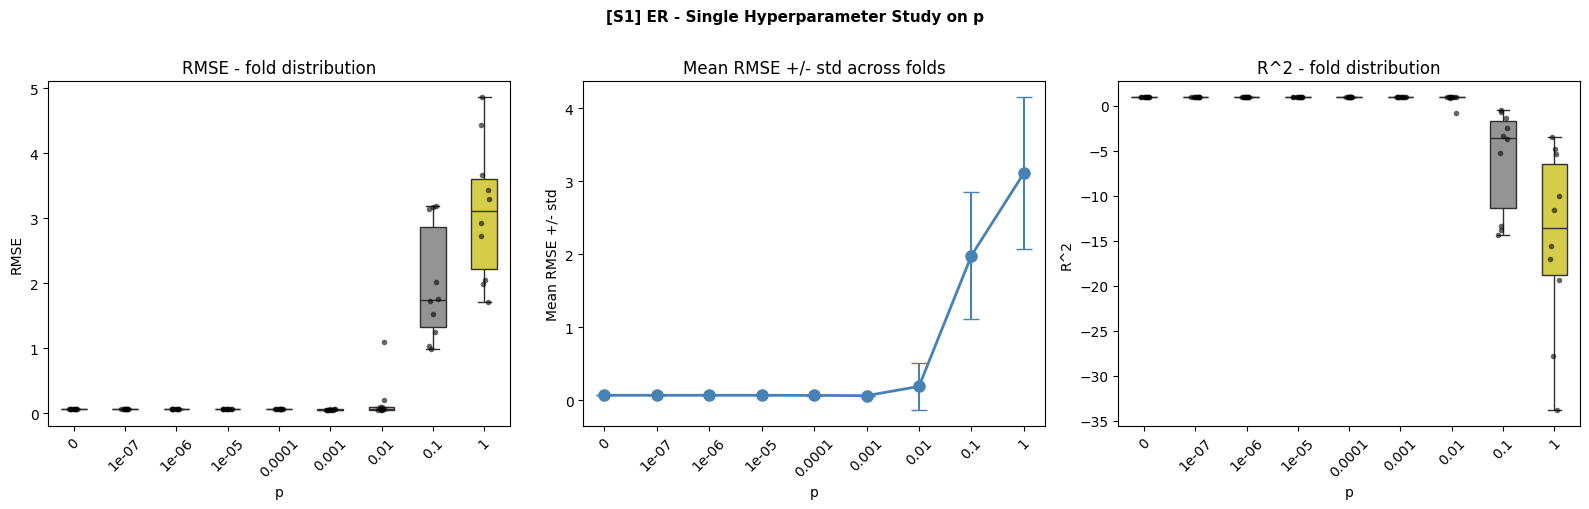

In [10]:
_res_s1 = study_results["S1"]
_er_s1 = _res_s1["ER"]["df"]
_er_p_vals_s1 = sorted(_er_s1["p"].unique())
_er_labels_s1 = {p: f"{p:g}" for p in _er_p_vals_s1}
plot_single_hp(
    _er_s1, "p", _er_p_vals_s1,
    label_map=_er_labels_s1,
    title="[S1] ER - Single Hyperparameter Study on p",
    save_path="single_hp_outputs_3/shs_S1_er_p.png",
)

### 4.2 WS — Joint Heatmap (k × p_rewire)

Watts–Strogatz joint grid for `S1`: each cell shows mean CV RMSE ± std.

    Figure saved -> single_hp_outputs_3/shs_S1_ws_heatmap.png


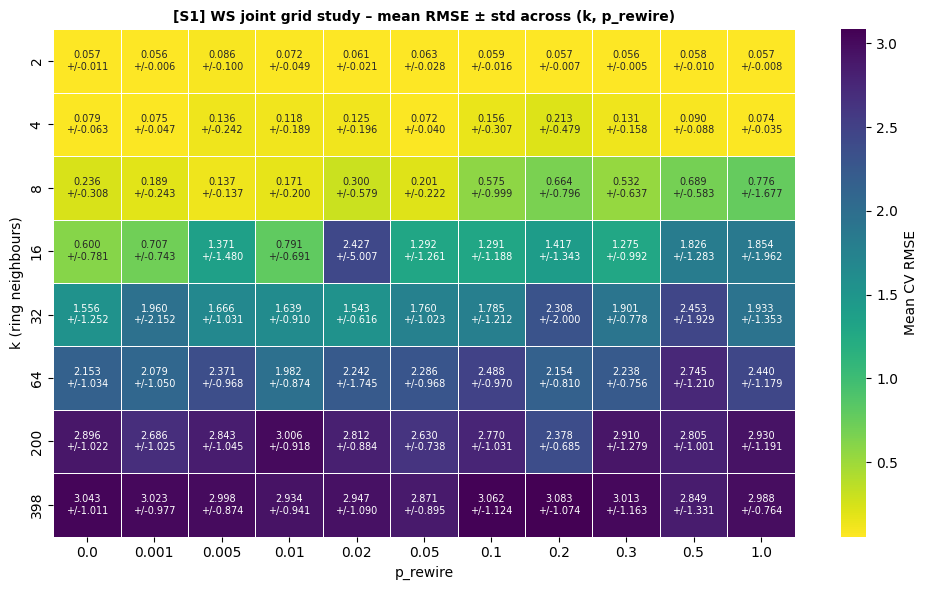

<Axes: title={'center': '[S1] WS joint grid study – mean RMSE ± std across (k, p_rewire)'}, xlabel='p_rewire', ylabel='k (ring neighbours)'>

In [11]:
plot_ws_heatmap(
    _res_s1["WS"]["summary"],
    title="[S1] WS joint grid study – mean RMSE ± std across (k, p_rewire)",
    save_path="single_hp_outputs_3/shs_S1_ws_heatmap.png",
)

### 4.3 BA — Single Hyperparameter Study on m

Sweep the Barabási–Albert edges-per-new-node `m` for `S1`.

    Figure saved -> single_hp_outputs_3/shs_S1_ba_m.png


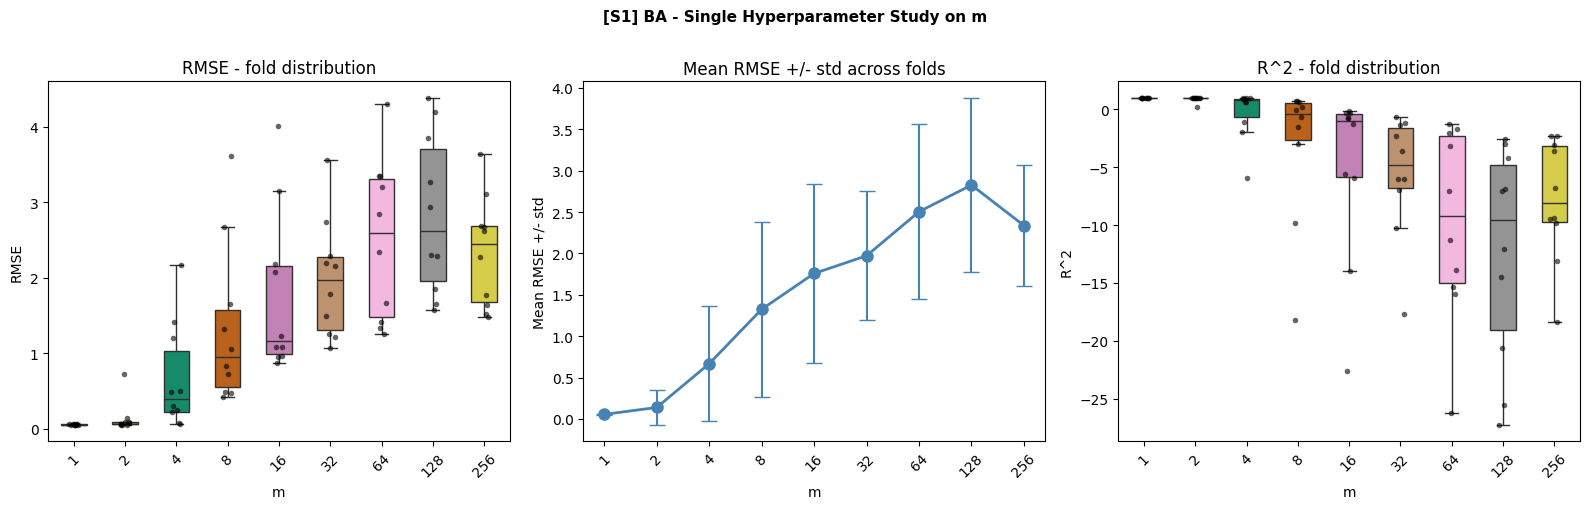

In [12]:
_ba_s1 = _res_s1["BA"]["df"]
_ba_m_vals_s1 = sorted(_ba_s1["m"].unique())
_ba_labels_s1 = {v: str(v) for v in _ba_m_vals_s1}
plot_single_hp(
    _ba_s1, "m", _ba_m_vals_s1,
    label_map=_ba_labels_s1,
    title="[S1] BA - Single Hyperparameter Study on m",
    save_path="single_hp_outputs_3/shs_S1_ba_m.png",
)

## 5. Topology Study - Signal S5
**11 frequencies + double AM envelope (T_AM=3500 x 500), sigma=1.20** - by this
point the signal combines rich spectral content with a two-timescale non-stationary
amplitude structure. The reservoir must simultaneously track fast oscillatory dynamics
and slow amplitude modulations spanning thousands of timesteps.

Expected behaviour: architecture differences should be more pronounced than in S1.
Topologies that support longer effective memory (WS small-world shortcuts, BA hubs)
may handle the slow AM envelope better than purely random ER connections.


In [13]:
study_results["S5"] = run_signal_study(
    "S5", SIGNALS["S5"], BEST_PARAMS_PER_SIGNAL["S5"],
    ER_P_VALUES, WS_K_VALUES, WS_PRW_VALUES, BA_M_VALUES,
)



  S5 - 11 freq + double AM, sigma=1.20
  11 frequencies + double AM envelope (T_AM=3500 x 500)
  Dataset: X=(14990, 10)  y=(14990, 1)
  ESN params: {'N': 50, 'sr': 1.3, 'lr': 0.1, 'ridge': 0.05, 'washout': 10}

[ER] Sweeping connection probability p ...
    [random] sweep 'p': 9 values x 10 folds = 90 evals

[WS] Joint sweep on (k, p_rewire) ...
    [small_world] joint grid on (k, p_rewire): 6 x 11 values x 10 folds = 660 evals

[BA] Sweeping edges-per-new-node m ...
    [scale_free] sweep 'm': 7 values x 10 folds = 70 evals

--------------------------------------------------------------
  Best ER  : p=0.1              -> mean RMSE = 1.29882
  Best WS  : k=2, p_rewire=0.001 -> mean RMSE = 1.28628 +/- 0.03451
  Best BA  : m=2               -> mean RMSE = 1.29282
  Elapsed  : 0.8 min


### 5.1 ER — Single Hyperparameter Study on p

Sweep the Erdős–Rényi connection probability `p` for `S5` using its own best ESN parameters.

    Figure saved -> single_hp_outputs_3/shs_S5_er_p.png


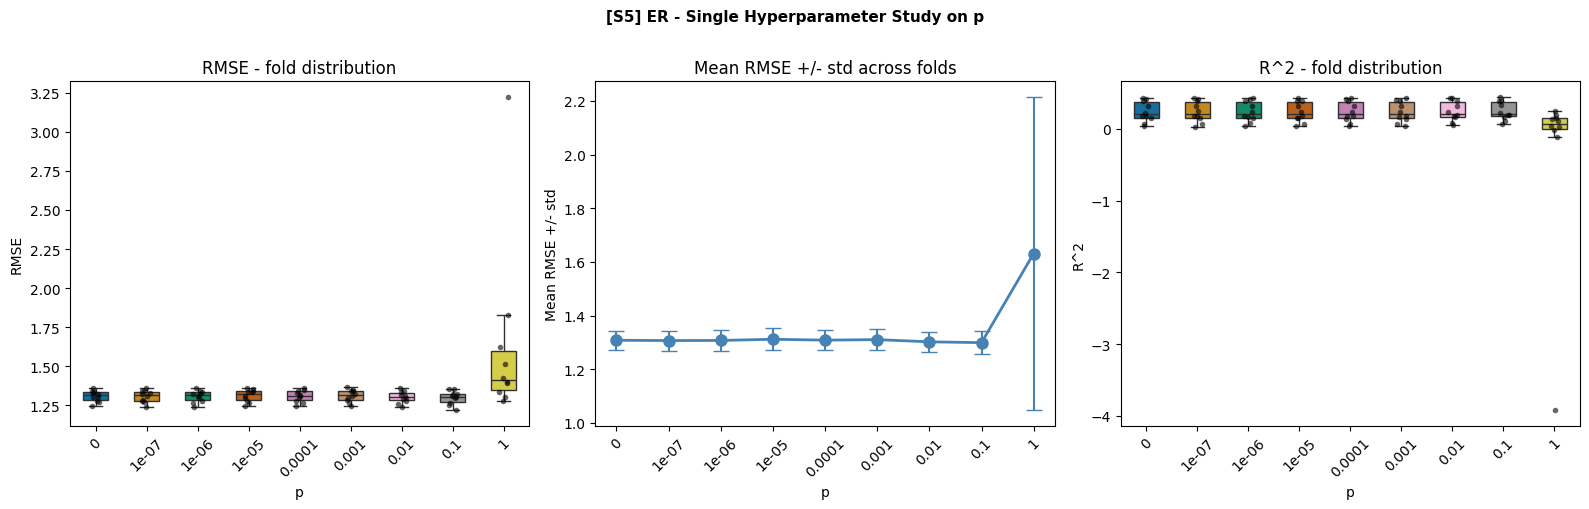

In [14]:
_res_s5 = study_results["S5"]
_er_s5 = _res_s5["ER"]["df"]
_er_p_vals_s5 = sorted(_er_s5["p"].unique())
_er_labels_s5 = {p: f"{p:g}" for p in _er_p_vals_s5}
plot_single_hp(
    _er_s5, "p", _er_p_vals_s5,
    label_map=_er_labels_s5,
    title="[S5] ER - Single Hyperparameter Study on p",
    save_path="single_hp_outputs_3/shs_S5_er_p.png",
)

### 5.2 WS — Joint Heatmap (k × p_rewire)

Watts–Strogatz joint grid for `S5`: each cell shows mean CV RMSE ± std.

    Figure saved -> single_hp_outputs_3/shs_S5_ws_heatmap.png


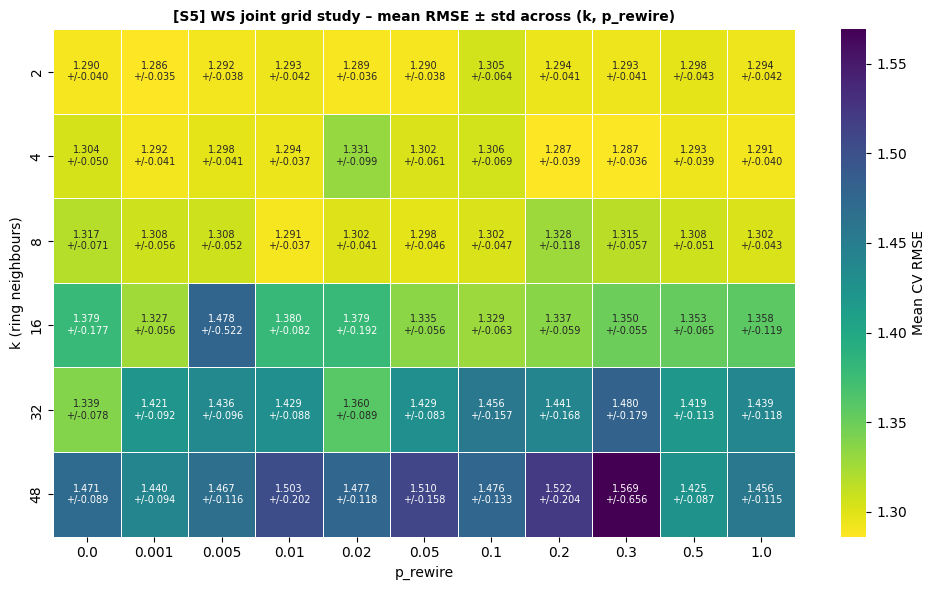

<Axes: title={'center': '[S5] WS joint grid study – mean RMSE ± std across (k, p_rewire)'}, xlabel='p_rewire', ylabel='k (ring neighbours)'>

In [15]:
plot_ws_heatmap(
    _res_s5["WS"]["summary"],
    title="[S5] WS joint grid study – mean RMSE ± std across (k, p_rewire)",
    save_path="single_hp_outputs_3/shs_S5_ws_heatmap.png",
)

### 5.3 BA — Single Hyperparameter Study on m

Sweep the Barabási–Albert edges-per-new-node `m` for `S5`.

    Figure saved -> single_hp_outputs_3/shs_S5_ba_m.png


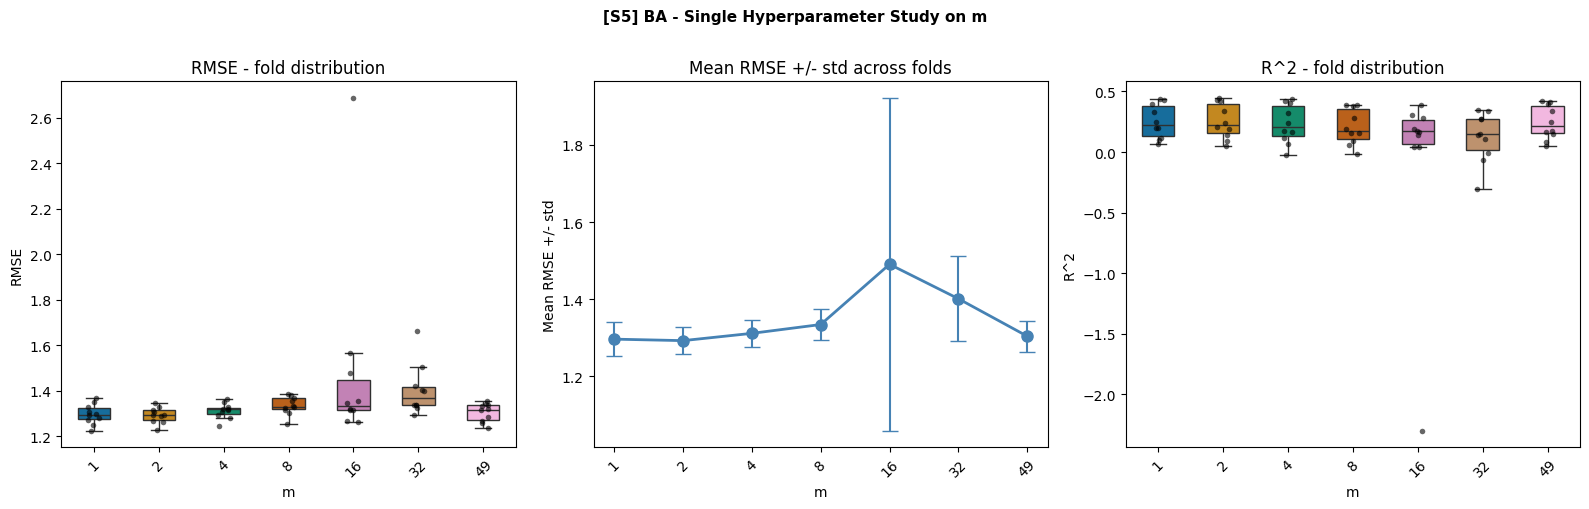

In [16]:
_ba_s5 = _res_s5["BA"]["df"]
_ba_m_vals_s5 = sorted(_ba_s5["m"].unique())
_ba_labels_s5 = {v: str(v) for v in _ba_m_vals_s5}
plot_single_hp(
    _ba_s5, "m", _ba_m_vals_s5,
    label_map=_ba_labels_s5,
    title="[S5] BA - Single Hyperparameter Study on m",
    save_path="single_hp_outputs_3/shs_S5_ba_m.png",
)

## 6. Topology Study - Signal S10
**16 frequencies + full non-linear complexity, sigma=3.00** - the hardest signal
in the suite combines all complexity mechanisms: triple AM envelope (3 timescales),
a frequency-modulated chirp component, abrupt regime switching, multiplicative
heteroscedastic noise, and a phase-coupled quadrature pair that creates a rotating
attractor-like structure.

Expected behaviour: this is the maximum-difficulty signal and inter-architecture
gaps should be most visible here. The combined non-stationarity may expose
fundamental limits of all three topology types.


In [17]:
study_results["S10"] = run_signal_study(
    "S10", SIGNALS["S10"], BEST_PARAMS_PER_SIGNAL["S10"],
    ER_P_VALUES, WS_K_VALUES, WS_PRW_VALUES, BA_M_VALUES,
)



  S10 - 16 freq + full complexity, sigma=3.00
  All mechanisms: triple AM, FM, regime switching, mult. noise, phase-coupled pair
  Dataset: X=(14990, 10)  y=(14990, 1)
  ESN params: {'N': 25, 'sr': 0.9, 'lr': 0.2, 'ridge': 0.05, 'washout': 10}

[ER] Sweeping connection probability p ...
    [random] sweep 'p': 9 values x 10 folds = 90 evals

[WS] Joint sweep on (k, p_rewire) ...
    [small_world] joint grid on (k, p_rewire): 5 x 11 values x 10 folds = 550 evals

[BA] Sweeping edges-per-new-node m ...
    [scale_free] sweep 'm': 6 values x 10 folds = 60 evals

--------------------------------------------------------------
  Best ER  : p=0.1              -> mean RMSE = 4.37089
  Best WS  : k=2, p_rewire=0.005 -> mean RMSE = 4.36285 +/- 0.06763
  Best BA  : m=1               -> mean RMSE = 4.36810
  Elapsed  : 0.7 min


### 6.1 ER — Single Hyperparameter Study on p

Sweep the Erdős–Rényi connection probability `p` for `S10` using its own best ESN parameters.

    Figure saved -> single_hp_outputs_3/shs_S10_er_p.png


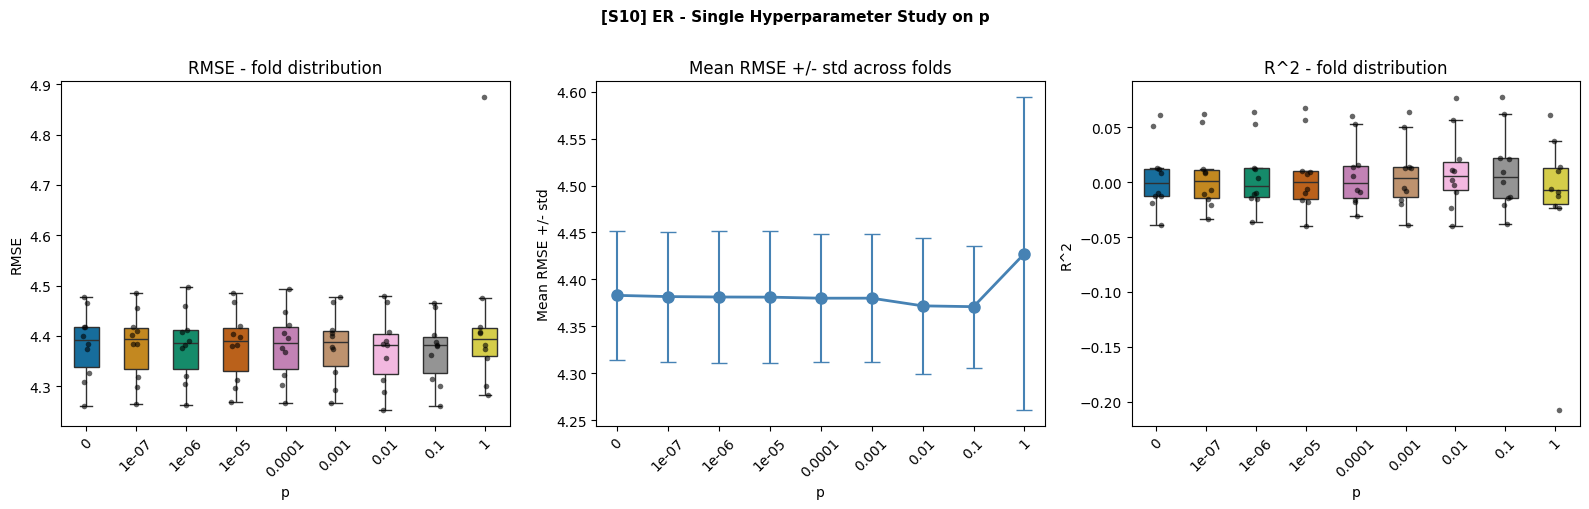

In [18]:
_res_s10 = study_results["S10"]
_er_s10 = _res_s10["ER"]["df"]
_er_p_vals_s10 = sorted(_er_s10["p"].unique())
_er_labels_s10 = {p: f"{p:g}" for p in _er_p_vals_s10}
plot_single_hp(
    _er_s10, "p", _er_p_vals_s10,
    label_map=_er_labels_s10,
    title="[S10] ER - Single Hyperparameter Study on p",
    save_path="single_hp_outputs_3/shs_S10_er_p.png",
)

### 6.2 WS — Joint Heatmap (k × p_rewire)

Watts–Strogatz joint grid for `S10`: each cell shows mean CV RMSE ± std.

    Figure saved -> single_hp_outputs_3/shs_S10_ws_heatmap.png


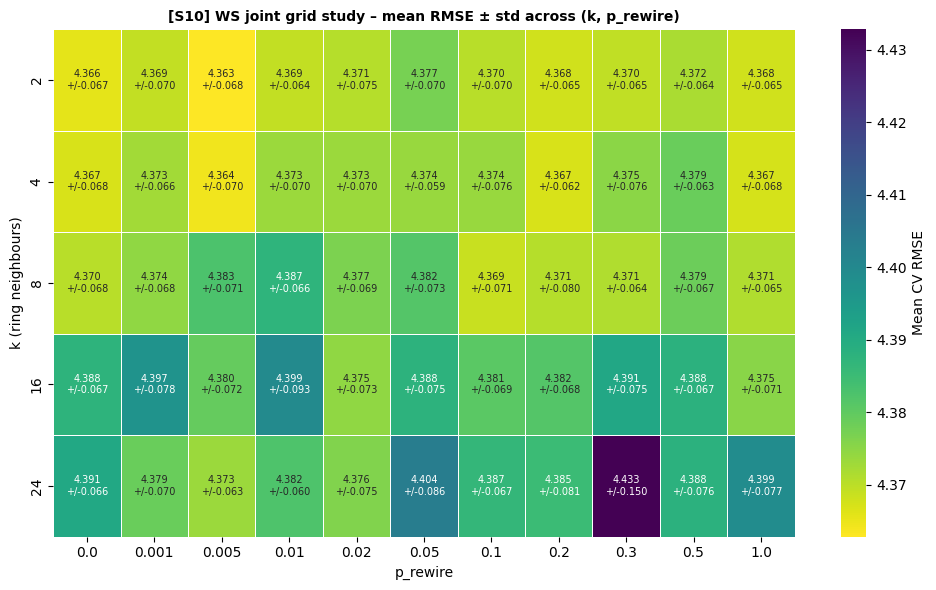

<Axes: title={'center': '[S10] WS joint grid study – mean RMSE ± std across (k, p_rewire)'}, xlabel='p_rewire', ylabel='k (ring neighbours)'>

In [19]:
plot_ws_heatmap(
    _res_s10["WS"]["summary"],
    title="[S10] WS joint grid study – mean RMSE ± std across (k, p_rewire)",
    save_path="single_hp_outputs_3/shs_S10_ws_heatmap.png",
)

### 6.3 BA — Single Hyperparameter Study on m

Sweep the Barabási–Albert edges-per-new-node `m` for `S10`.

    Figure saved -> single_hp_outputs_3/shs_S10_ba_m.png


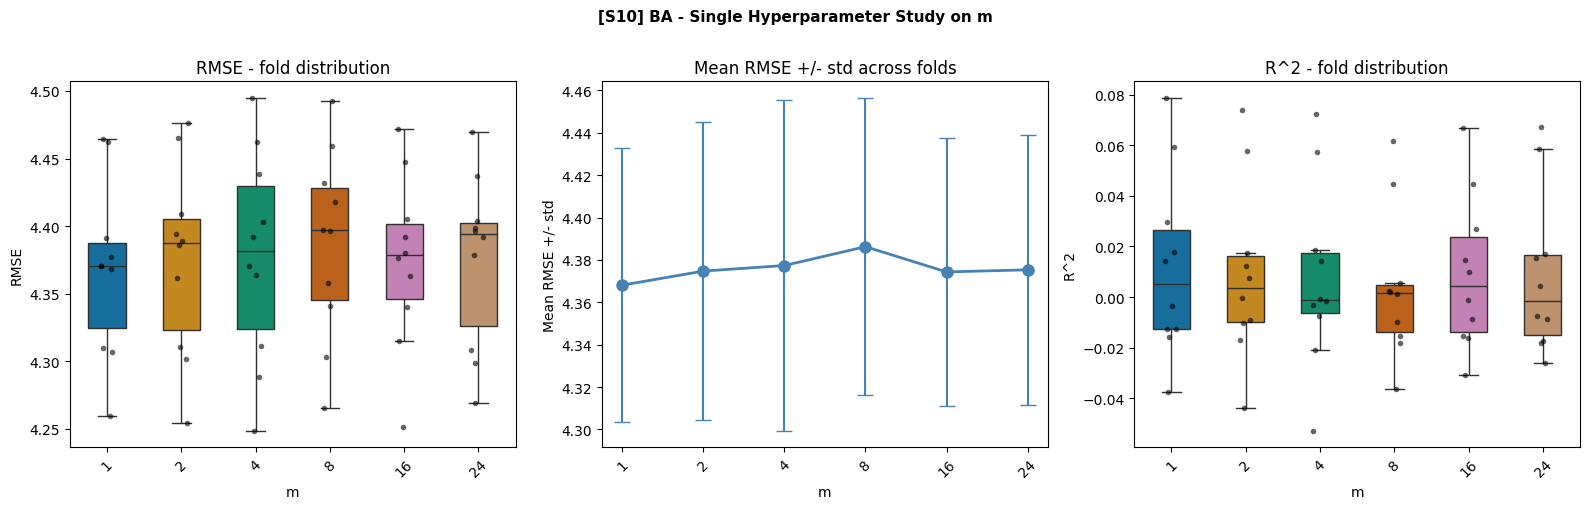

In [20]:
_ba_s10 = _res_s10["BA"]["df"]
_ba_m_vals_s10 = sorted(_ba_s10["m"].unique())
_ba_labels_s10 = {v: str(v) for v in _ba_m_vals_s10}
plot_single_hp(
    _ba_s10, "m", _ba_m_vals_s10,
    label_map=_ba_labels_s10,
    title="[S10] BA - Single Hyperparameter Study on m",
    save_path="single_hp_outputs_3/shs_S10_ba_m.png",
)

## 7. Cross-Signal Topology Summary (S1, S5, S10)
The three topology studies above — on the clean baseline (`S1`), the mid-complexity
signal (`S5`), and the hardest signal (`S10`) — bracket the full difficulty range.
The following section aggregates their results together with the per-signal
hyperparameter search to produce a compact architecture comparison.


In [21]:
# Verify all three detailed study results are available
for sig in ["S1", "S5", "S10"]:
    if sig in study_results:
        res = study_results[sig]
        print(f"{sig}: ER={res['ER']['best_rmse']:.5f}  "
              f"WS={res['WS']['best_rmse']:.5f}  "
              f"BA={res['BA']['best_rmse']:.5f}")
    else:
        print(f"{sig}: study not yet run")


S1: ER=0.06039  WS=0.05555  BA=0.05563
S5: ER=1.29882  WS=1.28628  BA=1.29282
S10: ER=4.37089  WS=4.36285  BA=4.36810


## 8. Cross-Signal Architecture Comparison Grid

This section collects the results from **all signal studies** (detailed sweeps for
S1, S5, and S10; best-params evaluation for the remaining signals) and builds a
compact comparison view:

1. **Summary table** - best RMSE and best structural parameter per `(signal x architecture)`
2. **ER / BA overlays** - single-parameter sensitivity curves across S1, S5, S10
3. **WS heatmaps** - one joint `(k, p_rewire)` heatmap per detailed signal
4. **Best prediction plots** - qualitative comparison of real vs predicted signal
5. **Architecture ranking** - how often each topology wins across the three detailed signals


In [22]:
# ---------------------------------------------------------------------------
# 8.1 Summary table - best RMSE and best param per (signal x architecture)
# ---------------------------------------------------------------------------
rows = []
for sig_name, res in study_results.items():
    esn_params = res["esn_params"]
    rows.append({
        "Signal": sig_name,
        "Label": res["label"],
        "n_freq": res["n_components"],
        "noise_sigma": res["noise_std"],
        "Extra": res["extra"],
        "Best N": esn_params["N"],
        "Best sr": esn_params["sr"],
        "Best lr": esn_params["lr"],
        "Best ridge": esn_params["ridge"],
        "Best washout": esn_params["washout"],
        "ER best p": res["ER"]["best_p"],
        "ER RMSE": res["ER"]["best_rmse"],
        "WS best k": res["WS"]["best_k"],
        "WS best prw": res["WS"]["best_prw"],
        "WS RMSE": res["WS"]["best_rmse"],
        "WS std": res["WS"]["best_std"],
        "BA best m": res["BA"]["best_m"],
        "BA RMSE": res["BA"]["best_rmse"],
    })

df_summary = pd.DataFrame(rows).set_index("Signal")

print("Best RMSE per signal x architecture\n")
cols_show = [
    "Label", "n_freq", "noise_sigma",
    "Best N", "Best sr", "Best lr", "Best ridge", "Best washout",
    "ER best p", "ER RMSE", "WS best k", "WS best prw", "WS RMSE", "WS std", "BA best m", "BA RMSE",
]
print(
    df_summary[cols_show].to_string(
        formatters={
            "noise_sigma": "{:.2f}".format,
            "Best sr": "{:.2f}".format,
            "Best lr": "{:.2f}".format,
            "Best ridge": "{:.0e}".format,
            "ER best p": lambda x: f"{x:g}",
            "ER RMSE": "{:.5f}".format,
            "WS best prw": lambda x: f"{x:g}",
            "WS RMSE": "{:.5f}".format,
            "WS std": "{:.5f}".format,
            "BA RMSE": "{:.5f}".format,
        }
    )
)

df_summary.to_csv("single_hp_outputs_3/summary_best_rmse.csv")
print("\nSaved -> single_hp_outputs_3/summary_best_rmse.csv")


Best RMSE per signal x architecture

                                              Label  n_freq noise_sigma  Best N Best sr Best lr Best ridge  Best washout ER best p ER RMSE  WS best k WS best prw WS RMSE  WS std  BA best m BA RMSE
Signal                                                                                                                                                                                              
S1                    S1 - NB1 baseline, sigma=0.05       3        0.05     400    1.10    0.05      1e-02            10     0.001 0.06039          2         0.3 0.05555 0.00535          1 0.05563
S5             S5 - 11 freq + double AM, sigma=1.20      11        1.20      50    1.30    0.10      5e-02            10       0.1 1.29882          2       0.001 1.28628 0.03451          2 1.29282
S10     S10 - 16 freq + full complexity, sigma=3.00      16        3.00      25    0.90    0.20      5e-02            10       0.1 4.37089          2       0.005 4.36285 0.067

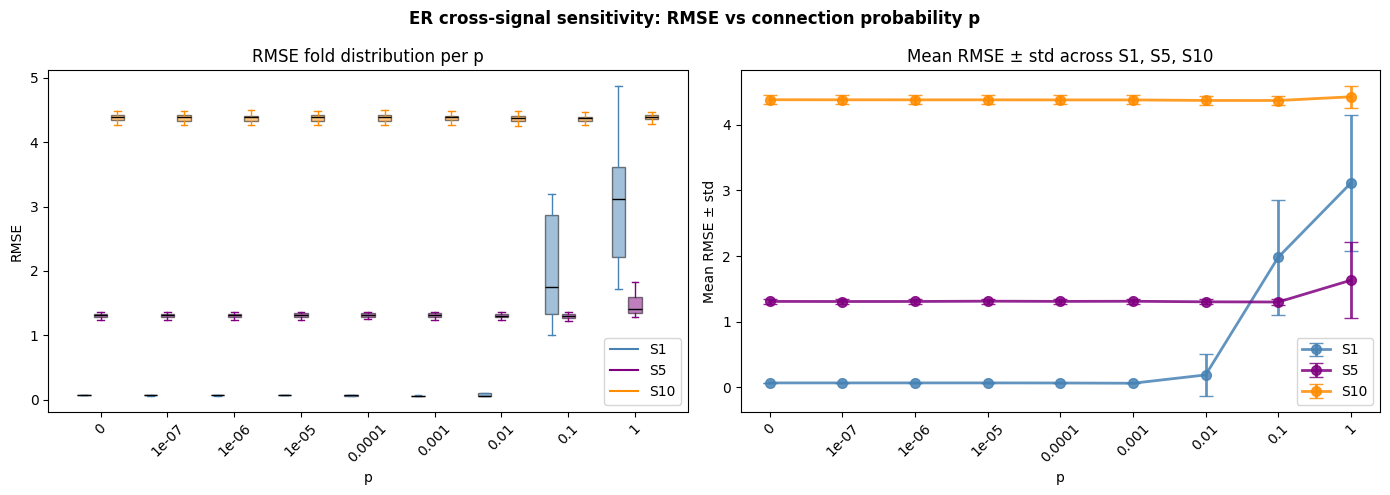

Figure saved -> single_hp_outputs_3/comparison_er_p.png


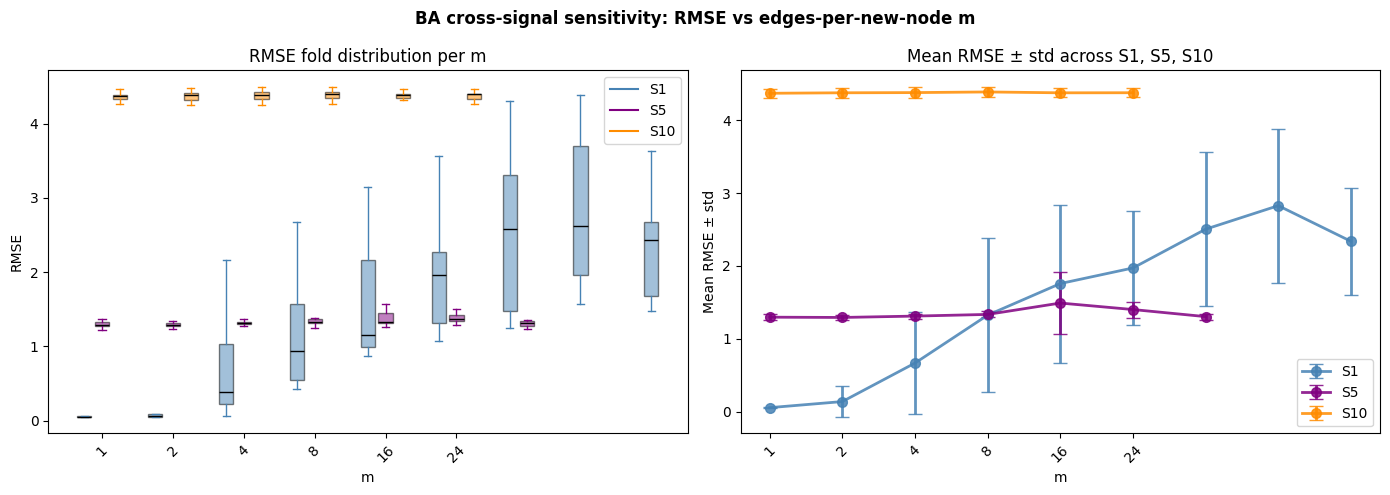

Figure saved -> single_hp_outputs_3/comparison_ba_m.png


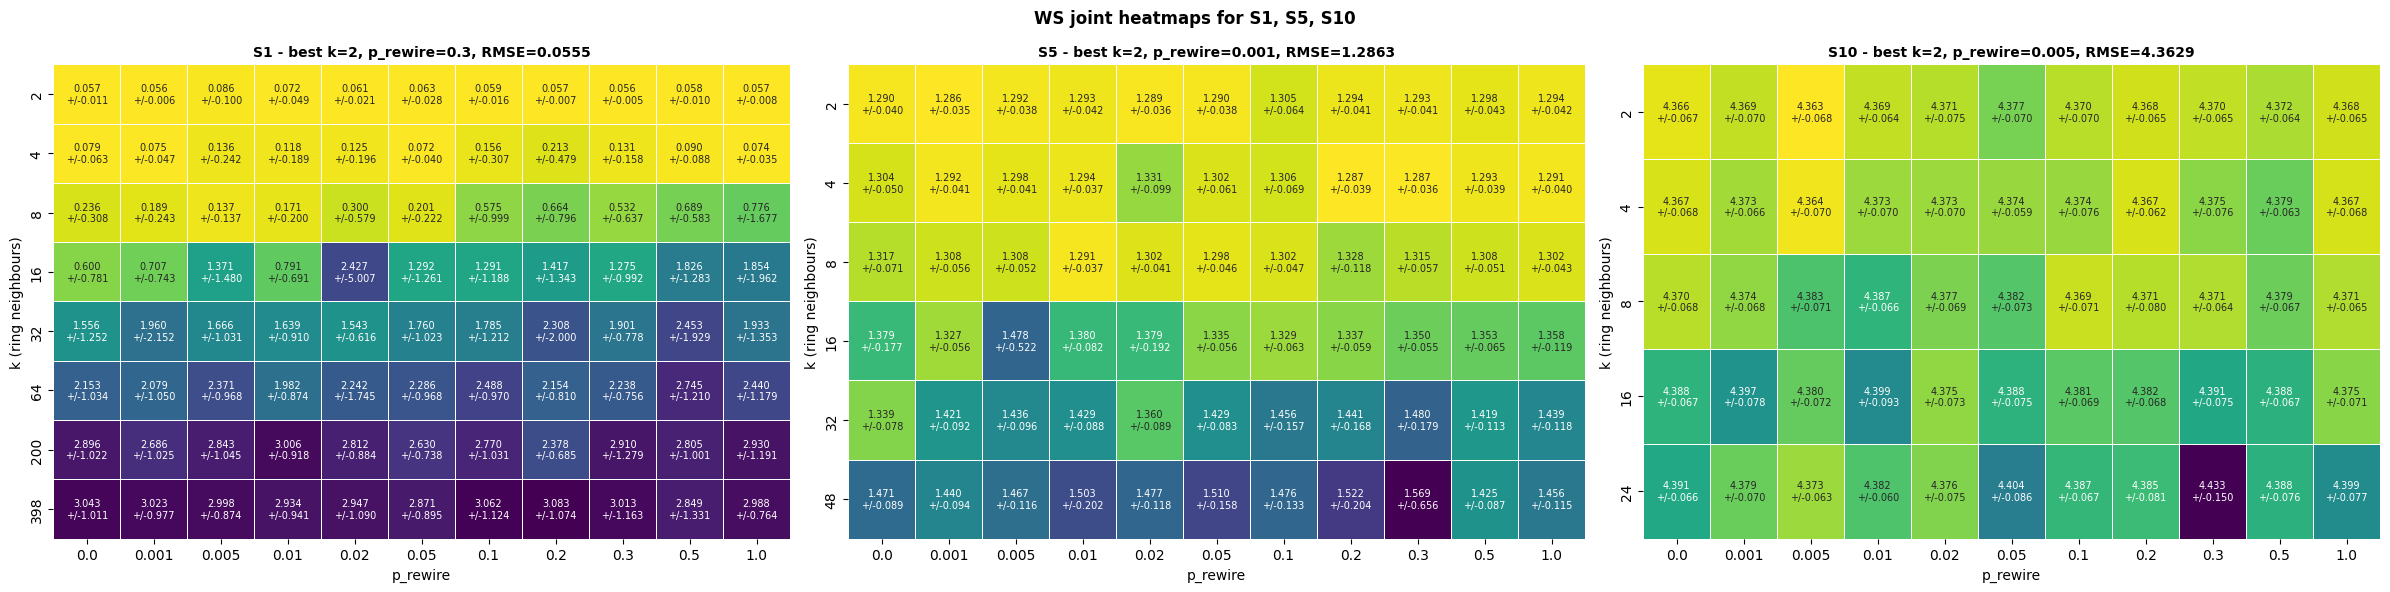

Figure saved -> single_hp_outputs_3/comparison_ws_heatmaps.png


In [23]:
# ---------------------------------------------------------------------------------------
# 8.2 Cross-signal sensitivity summary
# ER and BA: 1-D overlay comparing RMSE curves for S1, S5, S10
# WS: one joint heatmap per signal (k x p_rewire)
# ---------------------------------------------------------------------------------------

# --- ER (1-D overlay: RMSE vs p for S1, S5, S10) ---
sig_colors_map = {"S1": "steelblue", "S5": "purple", "S10": "darkorange"}
sigs_compare = ["S1", "S5", "S10"]

fig_er, axes_er = plt.subplots(1, 2, figsize=(14, 5))
fig_er.suptitle("ER cross-signal sensitivity: RMSE vs connection probability p", fontsize=12, fontweight="bold")

ax_box, ax_line = axes_er
for sig in sigs_compare:
    df_er_s = study_results[sig]["ER"]["df"]
    p_vals = sorted(df_er_s["p"].unique())
    mean_rmse = [df_er_s[df_er_s["p"] == p]["rmse"].mean() for p in p_vals]
    std_rmse  = [df_er_s[df_er_s["p"] == p]["rmse"].std()  for p in p_vals]
    ax_line.errorbar(
        range(len(p_vals)), mean_rmse, yerr=std_rmse,
        marker="o", capsize=5, linewidth=2, markersize=7,
        color=sig_colors_map[sig], label=sig, alpha=0.85,
    )
ax_line.set_xticks(range(len(p_vals)))
ax_line.set_xticklabels([f"{p:g}" for p in p_vals], rotation=45)
ax_line.set_xlabel("p")
ax_line.set_ylabel("Mean RMSE ± std")
ax_line.set_title("Mean RMSE ± std across S1, S5, S10")
ax_line.legend()

# box per signal overlaid
all_er_dfs = {sig: study_results[sig]["ER"]["df"] for sig in sigs_compare}
p_vals_all = sorted(all_er_dfs["S1"]["p"].unique())
offsets = [-0.25, 0, 0.25]
for sig, off in zip(sigs_compare, offsets):
    df_s = all_er_dfs[sig]
    positions = [i + off for i in range(len(p_vals_all))]
    data_per_p = [df_s[df_s["p"] == p]["rmse"].dropna().values for p in p_vals_all]
    bp = ax_box.boxplot(data_per_p, positions=positions, widths=0.2,
                        patch_artist=True, manage_ticks=False,
                        boxprops=dict(facecolor=sig_colors_map[sig], alpha=0.5),
                        medianprops=dict(color="black"),
                        whiskerprops=dict(color=sig_colors_map[sig]),
                        capprops=dict(color=sig_colors_map[sig]),
                        flierprops=dict(marker="", linestyle="none"))
    ax_box.plot([], [], color=sig_colors_map[sig], label=sig)
ax_box.set_xticks(range(len(p_vals_all)))
ax_box.set_xticklabels([f"{p:g}" for p in p_vals_all], rotation=45)
ax_box.set_xlabel("p")
ax_box.set_ylabel("RMSE")
ax_box.set_title("RMSE fold distribution per p")
ax_box.legend()

plt.tight_layout()
plt.savefig("single_hp_outputs_3/comparison_er_p.png", dpi=130, bbox_inches="tight")
plt.show()
print("Figure saved -> single_hp_outputs_3/comparison_er_p.png")

# --- BA (1-D overlay: RMSE vs m for S1, S5, S10) ---
fig_ba, axes_ba = plt.subplots(1, 2, figsize=(14, 5))
fig_ba.suptitle("BA cross-signal sensitivity: RMSE vs edges-per-new-node m", fontsize=12, fontweight="bold")

ax_box_ba, ax_line_ba = axes_ba
# Use m values from S1 (all three signals share the same BA_M_VALUES grid)
m_vals_s1 = sorted(study_results["S1"]["BA"]["df"]["m"].unique())
for sig in sigs_compare:
    df_ba_s = study_results[sig]["BA"]["df"]
    m_vals = sorted(df_ba_s["m"].unique())
    mean_rmse = [df_ba_s[df_ba_s["m"] == m]["rmse"].mean() for m in m_vals]
    std_rmse  = [df_ba_s[df_ba_s["m"] == m]["rmse"].std()  for m in m_vals]
    ax_line_ba.errorbar(
        range(len(m_vals)), mean_rmse, yerr=std_rmse,
        marker="o", capsize=5, linewidth=2, markersize=7,
        color=sig_colors_map[sig], label=sig, alpha=0.85,
    )
ax_line_ba.set_xticks(range(len(m_vals)))
ax_line_ba.set_xticklabels([str(m) for m in m_vals], rotation=45)
ax_line_ba.set_xlabel("m")
ax_line_ba.set_ylabel("Mean RMSE ± std")
ax_line_ba.set_title("Mean RMSE ± std across S1, S5, S10")
ax_line_ba.legend()

for sig, off in zip(sigs_compare, offsets):
    df_s = study_results[sig]["BA"]["df"]
    m_vals_sig = sorted(df_s["m"].unique())
    positions = [i + off for i in range(len(m_vals_sig))]
    data_per_m = [df_s[df_s["m"] == m]["rmse"].dropna().values for m in m_vals_sig]
    bp = ax_box_ba.boxplot(data_per_m, positions=positions, widths=0.2,
                           patch_artist=True, manage_ticks=False,
                           boxprops=dict(facecolor=sig_colors_map[sig], alpha=0.5),
                           medianprops=dict(color="black"),
                           whiskerprops=dict(color=sig_colors_map[sig]),
                           capprops=dict(color=sig_colors_map[sig]),
                           flierprops=dict(marker="", linestyle="none"))
    ax_box_ba.plot([], [], color=sig_colors_map[sig], label=sig)
ax_box_ba.set_xticks(range(len(m_vals_sig)))
ax_box_ba.set_xticklabels([str(m) for m in m_vals_sig], rotation=45)
ax_box_ba.set_xlabel("m")
ax_box_ba.set_ylabel("RMSE")
ax_box_ba.set_title("RMSE fold distribution per m")
ax_box_ba.legend()

plt.tight_layout()
plt.savefig("single_hp_outputs_3/comparison_ba_m.png", dpi=130, bbox_inches="tight")
plt.show()
print("Figure saved -> single_hp_outputs_3/comparison_ba_m.png")

sig_colors = ["steelblue", "purple", "darkorange"]
sig_names = list(study_results.keys())


# --- WS (Joint Heatmaps) ---
fig_ws, axes_ws = plt.subplots(1, 3, figsize=(24, 6))
fig_ws.suptitle("WS joint heatmaps for S1, S5, S10", fontsize=12, fontweight="bold")

for ax, sig in zip(axes_ws.flat, ["S1", "S5", "S10"]):
    ws_summary = study_results[sig]["WS"]["summary"]
    best_k = study_results[sig]["WS"]["best_k"]
    best_prw = study_results[sig]["WS"]["best_prw"]
    best_rmse = study_results[sig]["WS"]["best_rmse"]
    
    plot_ws_heatmap(
        ws_summary,
        title=f"{sig} - best k={best_k}, p_rewire={best_prw:g}, RMSE={best_rmse:.4f}",
        ax=ax,
        show=False,
    )

plt.tight_layout()
plt.savefig("single_hp_outputs_3/comparison_ws_heatmaps.png", dpi=130, bbox_inches="tight")
plt.show()

print("Figure saved -> single_hp_outputs_3/comparison_ws_heatmaps.png")

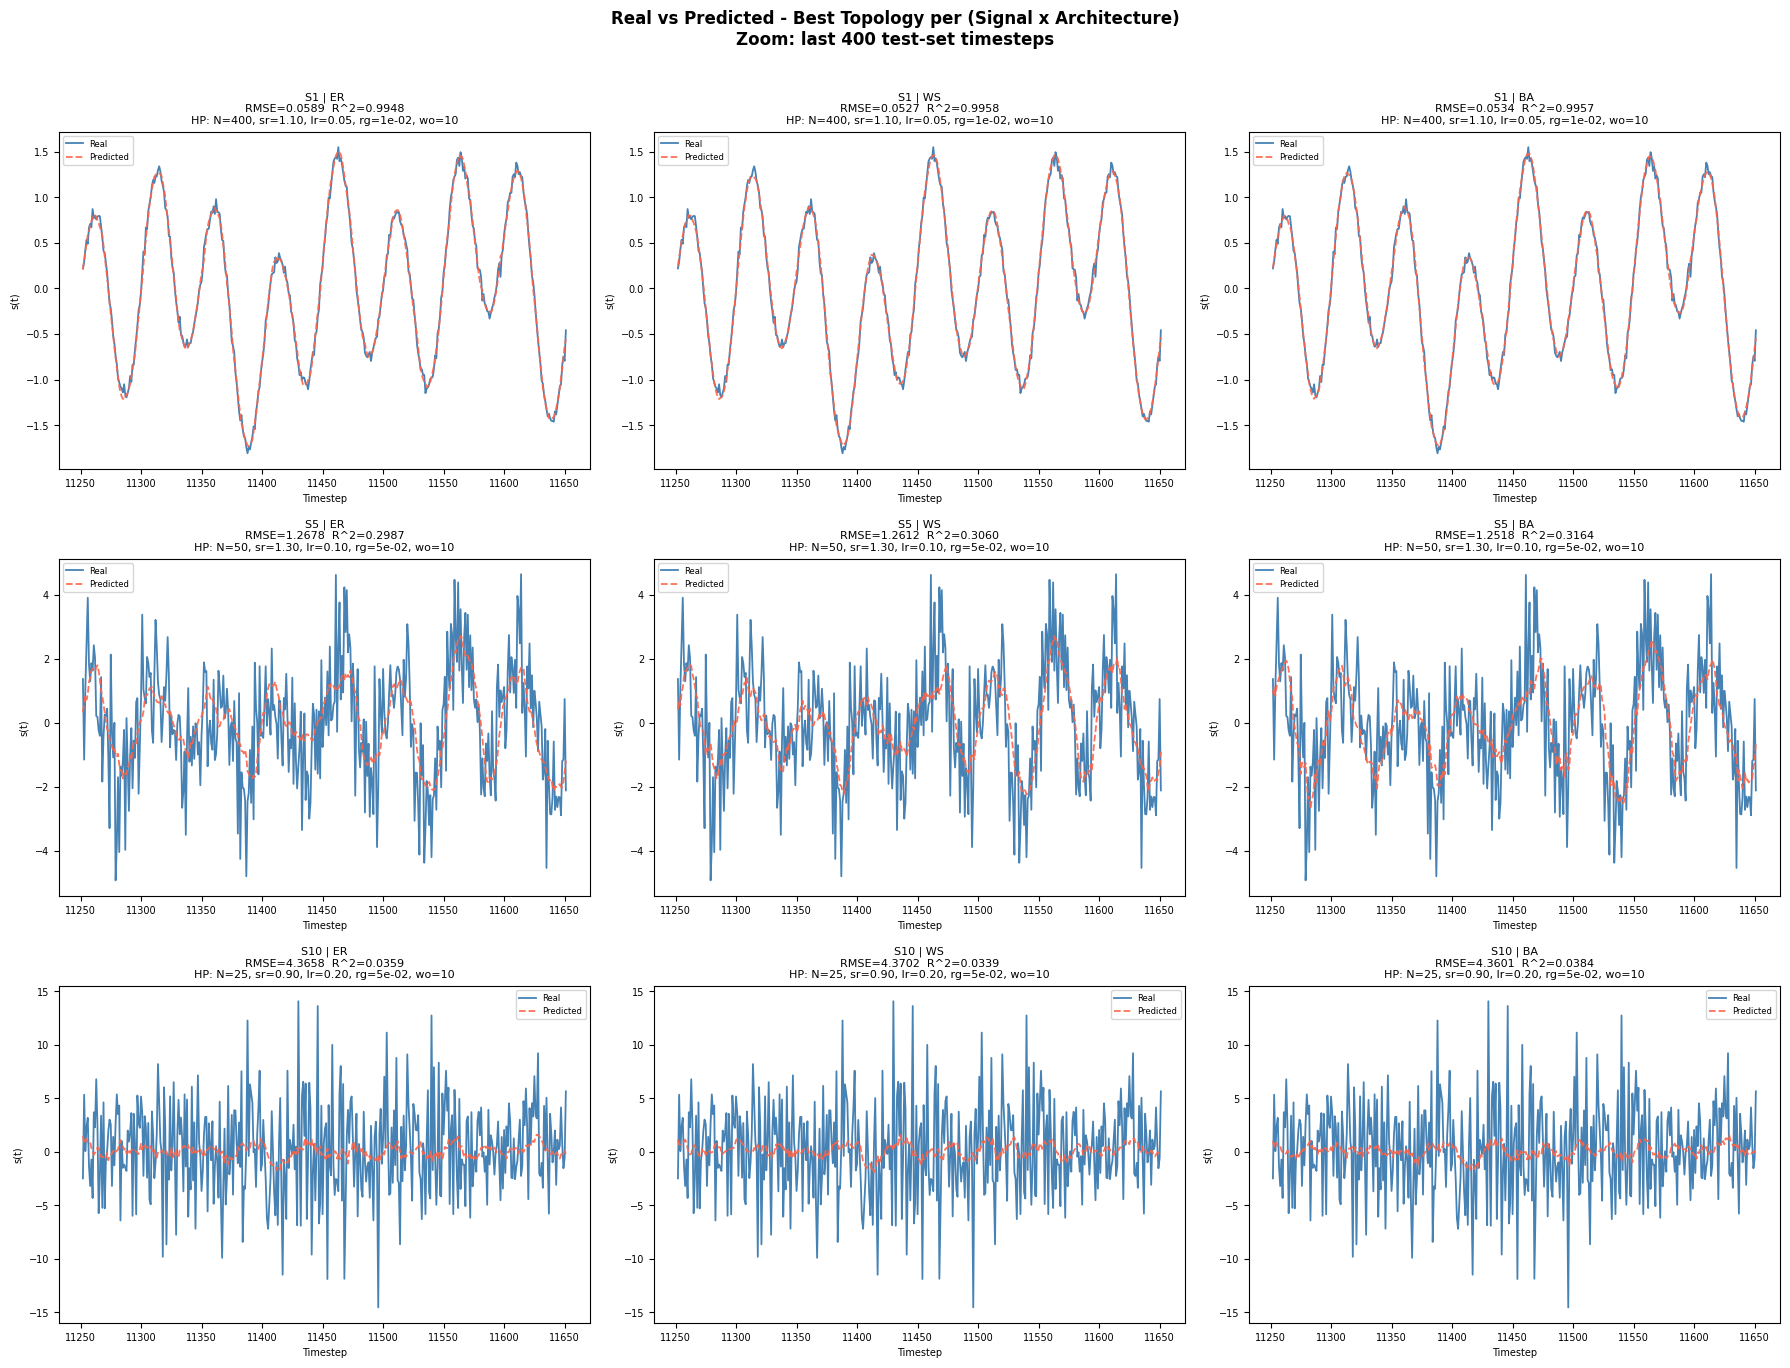

Figure saved -> single_hp_outputs_3/prediction_grid.png


In [24]:
# ---------------------------------------------------------------------------
# 8.3 Prediction grid - best topology per (signal x architecture)
# N rows (signals) x 3 columns (architectures), each showing zoom of test set
# ---------------------------------------------------------------------------
arch_configs = [
    ("ER", "random", lambda res: {"p": res["ER"]["best_p"]}),
    ("WS", "small_world", lambda res: {"k": res["WS"]["best_k"], "p_rewire": res["WS"]["best_prw"]}),
    ("BA", "scale_free", lambda res: {"m": res["BA"]["best_m"]}),
]

fig, axes = plt.subplots(len(sig_names), len(arch_configs), figsize=(18, 4.5 * len(sig_names)))
fig.suptitle(
    "Real vs Predicted - Best Topology per (Signal x Architecture)\n"
    "Zoom: last 400 test-set timesteps",
    fontsize=12, fontweight="bold", y=1.01
)

for row, sig_name in enumerate(sig_names):
    res = study_results[sig_name]
    sig_cfg = SIGNALS[sig_name]
    esn_params = res["esn_params"]
    signal = sig_cfg["data"]
    X_all_s, y_all_s = build_dataset(signal, lag=LAG)
    n = len(X_all_s)
    n_train = int(n * 0.75)
    X_te_s, y_te_s = X_all_s[n_train:], y_all_s[n_train:]
    t_test = np.arange(len(signal))[LAG + n_train:]
    zoom = 400

    for col, (arch_name, topo_str, get_params) in enumerate(arch_configs):
        ax = axes[row, col]
        topo_params = get_params(res)

        try:
            W, _ = make_reservoir_matrix(esn_params["N"], topo_str, topo_params)
            scaler = StandardScaler()
            X_tr_all = scaler.fit_transform(X_all_s[:n_train])
            X_te_all = scaler.transform(X_te_s)
            reservoir = Reservoir(units=esn_params["N"], W=W, lr=esn_params["lr"])
            model = reservoir >> Ridge(ridge=esn_params["ridge"])
            model.fit(X_tr_all, y_all_s[:n_train], warmup=int(esn_params["washout"]))
            y_pred = np.array(model.run(X_te_all)).reshape(-1)
            y_true = y_te_s.ravel()
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            r2 = r2_score(y_true, y_pred)

            ax.plot(t_test[:zoom], y_true[:zoom], lw=1.3, color="steelblue", label="Real")
            ax.plot(t_test[:zoom], y_pred[:zoom], lw=1.3, color="tomato", ls="--", alpha=0.9, label="Predicted")
            ax.set_title(
                f"{sig_name} | {arch_name}\n"
                f"RMSE={rmse:.4f}  R^2={r2:.4f}\n"
                f"HP: N={esn_params['N']}, sr={esn_params['sr']:.2f}, lr={esn_params['lr']:.2f}, "
                f"rg={esn_params['ridge']:.0e}, wo={esn_params['washout']}",
                fontsize=8,
            )
        except Exception as exc:
            ax.text(0.5, 0.5, f"Error:\n{exc}", transform=ax.transAxes, ha="center", va="center", fontsize=7, color="red")
            ax.set_title(f"{sig_name} | {arch_name}", fontsize=8)

        ax.set_xlabel("Timestep", fontsize=7)
        ax.set_ylabel("s(t)", fontsize=7)
        ax.legend(fontsize=6)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("single_hp_outputs_3/prediction_grid.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved -> single_hp_outputs_3/prediction_grid.png")


In [25]:
# ---------------------------------------------------------------------------------------
# 8.4 Architecture ranking - how often each topology wins across signals
# ---------------------------------------------------------------------------------------

print("Architecture ranking (best RMSE wins per signal)\n")
print(f"{'Signal':<40}  {'Winner':<18}  RMSE")
print("-" * 65)

wins = {"ER": 0, "WS": 0, "BA": 0}

for sig in sig_names:
    res = study_results[sig]
    
    rmse_dict = {
        "ER": res["ER"]["best_rmse"],
        "WS": res["WS"]["best_rmse"],
        "BA": res["BA"]["best_rmse"],
    }
    
    winner = min(rmse_dict, key=rmse_dict.get)
    wins[winner] += 1
    label = res["label"]
    
    print(f"  {label:<38}  {winner:<18}  {rmse_dict[winner]:.5f}")

print("-" * 65)
print(f"  Wins:  ER={wins['ER']}  WS={wins['WS']}  BA={wins['BA']}")

print("\nRelative RMSE degradation S1 -> S10 (via detailed studies):")

for arch in ["ER", "WS", "BA"]:
    rmse_s1 = study_results["S1"][arch]["best_rmse"]
    rmse_s10 = study_results["S10"][arch]["best_rmse"]
    
    pct = 100.0 * (rmse_s10 - rmse_s1) / rmse_s1
    
    print(f"  {arch}: {rmse_s1:.5f} -> {rmse_s10:.5f}  (+{pct:.1f}%)")

Architecture ranking (best RMSE wins per signal)

Signal                                    Winner              RMSE
-----------------------------------------------------------------
  S1 - NB1 baseline, sigma=0.05           WS                  0.05555
  S5 - 11 freq + double AM, sigma=1.20    WS                  1.28628
  S10 - 16 freq + full complexity, sigma=3.00  WS                  4.36285
-----------------------------------------------------------------
  Wins:  ER=0  WS=3  BA=0

Relative RMSE degradation S1 -> S10 (via detailed studies):
  ER: 0.06039 -> 4.37089  (+7137.9%)
  WS: 0.05555 -> 4.36285  (+7754.3%)
  BA: 0.05563 -> 4.36810  (+7752.5%)


## 9. Final Comparison - Mean RMSE vs. Signal Difficulty

Using the **canonical best topology parameters** fixed in Section 3.3, we evaluate
all three architectures on the **original ten-signal suite only**.

Unlike the previous version, there are no extra `S11-S20` signals here. Each of
`S1-S10` uses its own optimised ESN hyperparameters, and `S1` is anchored to the
saved Notebook 1 Phase-A reference when those artifacts are available.

- **x-axis** - signal difficulty rank (`S1` ... `S10`), with labels showing the number
  of sine components and the noise level `sigma`
- **top panel** - mean RMSE across 10 CV folds for ER, WS, and BA (`+/- 1 std` shaded band)
- **bottom panel** - per-signal optimised ESN hyperparameters


Evaluating canonical topologies across 10 optimised signals (10-fold CV) ...

S1: ESN params = {'N': 400, 'sr': 1.1, 'lr': 0.05, 'ridge': 0.01, 'washout': 10}
  [ER] mean RMSE = 0.06114 +/- 0.00208
  [WS] mean RMSE = 0.06035 +/- 0.01871
  [BA] mean RMSE = 0.06266 +/- 0.02041

S2: ESN params = {'N': 400, 'sr': 0.9, 'lr': 0.05, 'ridge': 0.05, 'washout': 10}
  [ER] mean RMSE = 0.25583 +/- 0.00613
  [WS] mean RMSE = 0.34115 +/- 0.18546
  [BA] mean RMSE = 0.38176 +/- 0.35188

S3: ESN params = {'N': 100, 'sr': 1.1, 'lr': 0.1, 'ridge': 0.05, 'washout': 10}
  [ER] mean RMSE = 0.64037 +/- 0.01703
  [WS] mean RMSE = 0.62484 +/- 0.01857
  [BA] mean RMSE = 0.64457 +/- 0.06624

S4: ESN params = {'N': 100, 'sr': 0.9, 'lr': 0.1, 'ridge': 0.05, 'washout': 10}
  [ER] mean RMSE = 0.94444 +/- 0.00931
  [WS] mean RMSE = 0.92646 +/- 0.01690
  [BA] mean RMSE = 0.93107 +/- 0.01817

S5: ESN params = {'N': 50, 'sr': 1.3, 'lr': 0.1, 'ridge': 0.05, 'washout': 10}
  [ER] mean RMSE = 1.30886 +/- 0.03452
  [WS] mea

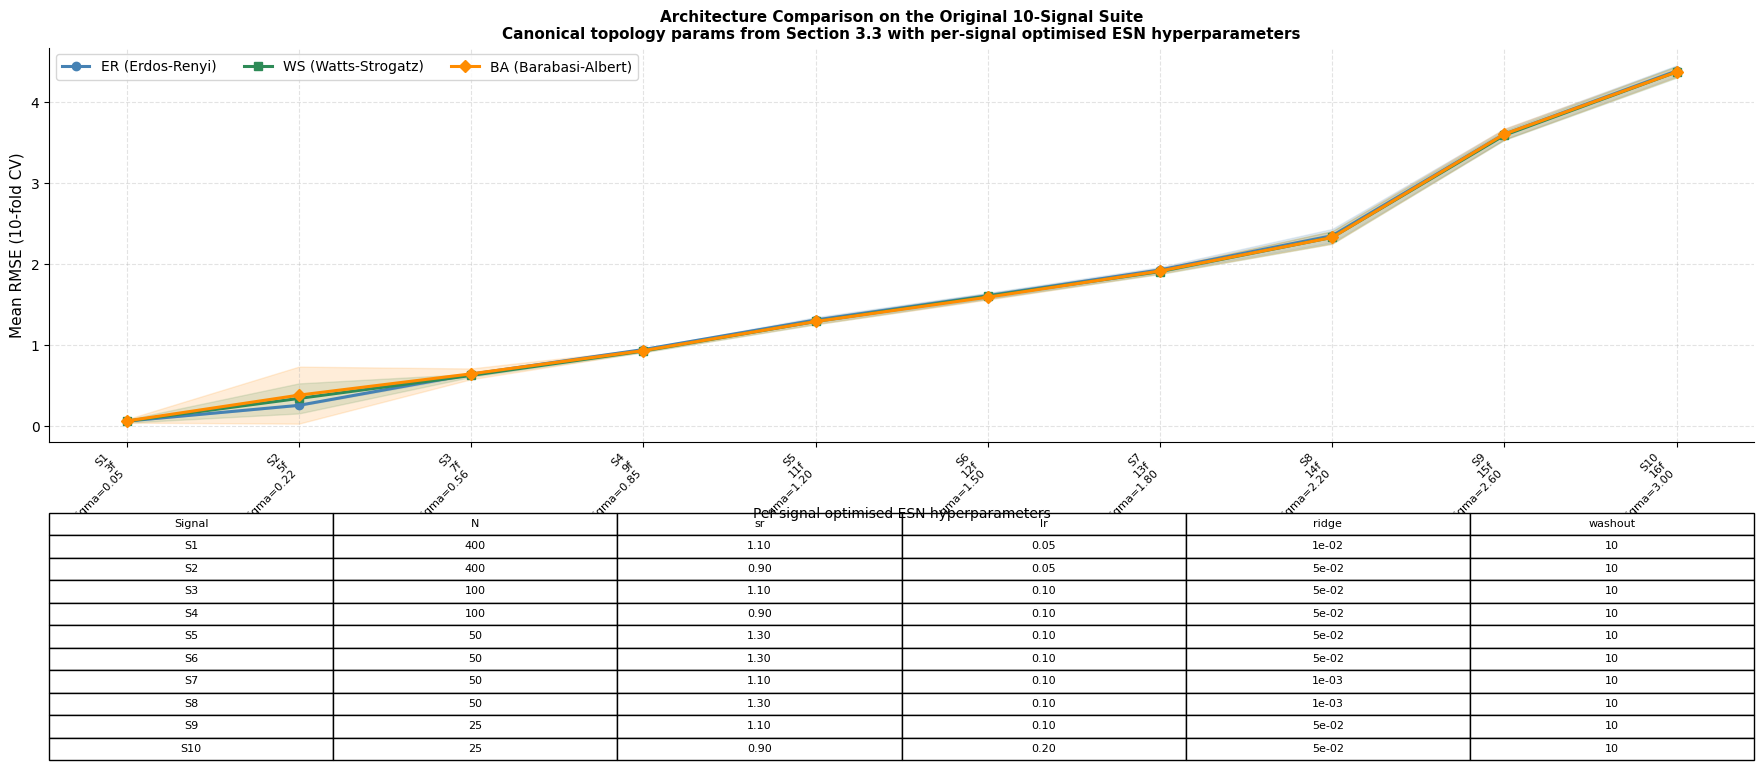

Figure saved -> single_hp_outputs_3/final_rmse_vs_difficulty.png
Saved -> single_hp_outputs_3/final_rmse_first10_summary.csv
Saved -> single_hp_outputs_3/final_rmse_extended_summary.csv

Final numeric summary

Signal  n_freq noise_sigma   N   sr   lr ridge  washout ER_mean  ER_std WS_mean  WS_std BA_mean  BA_std
    S1       3        0.05 400 1.10 0.05 1e-02       10 0.06114 0.00208 0.06035 0.01871 0.06266 0.02041
    S2       5        0.22 400 0.90 0.05 5e-02       10 0.25583 0.00613 0.34115 0.18546 0.38176 0.35188
    S3       7        0.56 100 1.10 0.10 5e-02       10 0.64037 0.01703 0.62484 0.01857 0.64457 0.06624
    S4       9        0.85 100 0.90 0.10 5e-02       10 0.94444 0.00931 0.92646 0.01690 0.93107 0.01817
    S5      11        1.20  50 1.30 0.10 5e-02       10 1.30886 0.03452 1.29163 0.03645 1.29086 0.03404
    S6      12        1.50  50 1.30 0.10 5e-02       10 1.60934 0.03448 1.60279 0.03484 1.59112 0.03149
    S7      13        1.80  50 1.10 0.10 1e-03       10 1.9275

In [26]:
# ---------------------------------------------------------------------------
# Final comparison on the 10 optimised signals
# ---------------------------------------------------------------------------
canonical_topo = {
    "ER": ("random", {"p": CANONICAL_ER_P}),
    "WS": ("small_world", {"k": CANONICAL_WS_K, "p_rewire": CANONICAL_WS_PRW}),
    "BA": ("scale_free", {"m": CANONICAL_BA_M}),
}

comparison_signals = {name: SIGNALS[name] for name in SIGNAL_ORDER}
results_final = {arch: {} for arch in canonical_topo}
tscv_final = TimeSeriesSplit(n_splits=N_SPLITS)

print(
    f"Evaluating canonical topologies across {len(comparison_signals)} optimised signals "
    f"({N_SPLITS}-fold CV) ...\n"
)

for sig_name, sig_cfg in comparison_signals.items():
    esn_params = BEST_PARAMS_PER_SIGNAL[sig_name]
    X_s, y_s = build_dataset(sig_cfg["data"], lag=LAG)
    print(f"{sig_name}: ESN params = {esn_params}")

    for arch_name, (topology, topo_params) in canonical_topo.items():
        fold_rmses = []
        W, info = make_reservoir_matrix(esn_params["N"], topology, topo_params)

        for train_idx, test_idx in tscv_final.split(X_s):
            X_tr_f, y_tr_f = X_s[train_idx], y_s[train_idx]
            X_te_f, y_te_f = X_s[test_idx], y_s[test_idx]

            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr_f)
            X_te = scaler.transform(X_te_f)

            reservoir = Reservoir(units=esn_params["N"], W=W, lr=esn_params["lr"])
            model = reservoir >> Ridge(ridge=esn_params["ridge"])
            model.fit(X_tr, y_tr_f, warmup=int(esn_params["washout"]))
            y_pred = np.array(model.run(X_te)).reshape(-1)
            fold_rmses.append(np.sqrt(mean_squared_error(y_te_f.ravel(), y_pred)))

        results_final[arch_name][sig_name] = {
            "mean": float(np.mean(fold_rmses)),
            "std": float(np.std(fold_rmses)),
            "folds": fold_rmses,
            "density": info["actual_density"],
        }
        print(
            f"  [{arch_name}] mean RMSE = {np.mean(fold_rmses):.5f} +/- {np.std(fold_rmses):.5f}"
        )
    print()

sig_order = list(comparison_signals.keys())
x_pos = np.arange(len(sig_order))
x_labels = [
    f"{sig}\n{comparison_signals[sig]['n_components']}f\nsigma={comparison_signals[sig]['noise_std']:.2f}"
    for sig in sig_order
]

arch_styles = {
    "ER": {"color": "steelblue", "marker": "o", "label": "ER (Erdos-Renyi)"},
    "WS": {"color": "seagreen", "marker": "s", "label": "WS (Watts-Strogatz)"},
    "BA": {"color": "darkorange", "marker": "D", "label": "BA (Barabasi-Albert)"},
}

fig = plt.figure(figsize=(22, 9))
gs = fig.add_gridspec(2, 1, height_ratios=[3.4, 1.8], hspace=0.30)
ax_main = fig.add_subplot(gs[0, 0])
ax_table = fig.add_subplot(gs[1, 0])
ax_table.axis("off")

for arch_name, style in arch_styles.items():
    means = [results_final[arch_name][sig]["mean"] for sig in sig_order]
    stds = [results_final[arch_name][sig]["std"] for sig in sig_order]

    ax_main.plot(
        x_pos, means,
        color=style["color"],
        marker=style["marker"],
        linewidth=2.2,
        markersize=6,
        label=style["label"],
    )
    ax_main.fill_between(
        x_pos,
        [m - sd for m, sd in zip(means, stds)],
        [m + sd for m, sd in zip(means, stds)],
        color=style["color"],
        alpha=0.15,
    )

ax_main.set_ylabel(f"Mean RMSE ({N_SPLITS}-fold CV)", fontsize=11)
ax_main.set_title(
    "Architecture Comparison on the Original 10-Signal Suite\n"
    "Canonical topology params from Section 3.3 with per-signal optimised ESN hyperparameters",
    fontsize=11,
    fontweight="bold",
)
ax_main.grid(True, linestyle="--", alpha=0.35)
ax_main.legend(fontsize=10, ncol=3, loc="upper left")
ax_main.set_xlabel("Signal difficulty rank (label = ID / sine count / noise sigma)", fontsize=11)
ax_main.set_xticks(x_pos)
ax_main.set_xticklabels(x_labels, fontsize=8, rotation=45, ha="right")

hp_rows = []
for sig in sig_order:
    p = BEST_PARAMS_PER_SIGNAL[sig]
    hp_rows.append([
        sig,
        p["N"],
        f"{p['sr']:.2f}",
        f"{p['lr']:.2f}",
        f"{p['ridge']:.0e}",
        p["washout"],
    ])

table = ax_table.table(
    cellText=hp_rows,
    colLabels=["Signal", "N", "sr", "lr", "ridge", "washout"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.0, 1.35)
ax_table.set_title("Per-signal optimised ESN hyperparameters", fontsize=10, pad=10)

sns.despine(ax=ax_main)
plt.tight_layout()
plt.savefig("single_hp_outputs_3/final_rmse_vs_difficulty.png", dpi=130, bbox_inches="tight")
plt.show()
print("Figure saved -> single_hp_outputs_3/final_rmse_vs_difficulty.png")

summary_rows = []
for sig in sig_order:
    p = BEST_PARAMS_PER_SIGNAL[sig]
    summary_rows.append({
        "Signal": sig,
        "n_freq": comparison_signals[sig]["n_components"],
        "noise_sigma": comparison_signals[sig]["noise_std"],
        "N": p["N"],
        "sr": p["sr"],
        "lr": p["lr"],
        "ridge": p["ridge"],
        "washout": p["washout"],
        "ER_mean": results_final["ER"][sig]["mean"],
        "ER_std": results_final["ER"][sig]["std"],
        "WS_mean": results_final["WS"][sig]["mean"],
        "WS_std": results_final["WS"][sig]["std"],
        "BA_mean": results_final["BA"][sig]["mean"],
        "BA_std": results_final["BA"][sig]["std"],
    })

df_final_summary = pd.DataFrame(summary_rows)
df_final_summary.to_csv("single_hp_outputs_3/final_rmse_first10_summary.csv", index=False)
df_final_summary.to_csv("single_hp_outputs_3/final_rmse_extended_summary.csv", index=False)

print("Saved -> single_hp_outputs_3/final_rmse_first10_summary.csv")
print("Saved -> single_hp_outputs_3/final_rmse_extended_summary.csv")
print("\nFinal numeric summary\n")
print(
    df_final_summary.to_string(
        index=False,
        formatters={
            "noise_sigma": "{:.2f}".format,
            "sr": "{:.2f}".format,
            "lr": "{:.2f}".format,
            "ridge": "{:.0e}".format,
            "ER_mean": "{:.5f}".format,
            "ER_std": "{:.5f}".format,
            "WS_mean": "{:.5f}".format,
            "WS_std": "{:.5f}".format,
            "BA_mean": "{:.5f}".format,
            "BA_std": "{:.5f}".format,
        },
    )
)


The **Arch gap plot** shows the mean RMSE difference between the best and the worst
topology curves across the full 10-signal suite. On the simpler signals (S1-S3) the
gap is small. It grows progressively as complexity increases, with the largest
separation observed around S8-S10 where FM, regime switching, and multiplicative
noise combine. Even so, the architecture effect remains smaller than the difficulty
effect: total RMSE dominates over inter-topology differences, suggesting that ESN
hyperparameter choice matters more than reservoir topology for these signals.
